# Inference for validation and train 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
train_df = pd.read_csv('../results/validation_train.csv')
val_df_robust = pd.read_csv('../results/robust_validation_robust.csv')
val_df_soft = pd.read_csv('../results/soft_validation_soft.csv')

In [3]:
train_df['E_delta'] = train_df['Exd'] - train_df['Exn']
val_df_robust['E_delta'] = val_df_robust['Exd'] - val_df_robust['Exn']
val_df_soft['E_delta'] = val_df_soft['Exd'] - val_df_soft['Exn']
# positive delta means that the model is more confident in the decision
train_df['E_delta_sign'] = np.sign(train_df['E_delta'])
val_df_robust['E_delta_sign'] = np.sign(val_df_robust['E_delta'])
val_df_soft['E_delta_sign'] = np.sign(val_df_soft['E_delta'])

In [5]:
train_df.head()

,id,Exd,Exn,seq_len,lossg,lossd,E_delta,E_delta_sign
0,['1TKN_1_A__AlphaFold2'],534.892395,12213.602540,110,1.0,3.169392,-11678.710145,-1.0
1,['1TKN_1_A__RoseTTAFold'],1073.857910,12446.387700,110,1.0,2.532148,-11372.529790,-1.0
2,['2V66_1_B__RoseTTAFold'],4179.675293,14986.077150,111,1.0,1.522757,-10806.401857,-1.0
3,['2R7G_d2r7gc2__RoseTTAFold'],3501.185059,12917.522460,143,1.0,1.545156,-9416.337401,-1.0
4,['4V7O_15_AE__RoseTTAFoldNT'],571.917358,8007.006348,76,1.0,2.706555,-7435.088990,-1.0


In [6]:
print('Train set')
display(train_df.describe())
print('Validation set - Robust')
display(val_df_robust.describe())
print('Validation set - Soft')
display(val_df_soft.describe())

Train set


,Exd,Exn,seq_len,lossg,lossd,E_delta,E_delta_sign
count,33844.000000,33844.000000,33844.000000,33844.000000,33844.000000,33844.000000,33844.000000
mean,14819.927421,40.279498,204.314738,0.275258,0.014264,14779.647923,0.985699
std,14012.950166,436.248395,135.711293,0.439401,0.120627,14044.761592,0.168517
min,0.056043,0.038591,34.000000,0.000000,0.000018,-11678.710145,-1.000000
25%,4759.970703,0.274600,104.000000,0.000000,0.000077,4697.445607,1.000000
50%,10697.492675,0.460561,165.000000,0.000000,0.000141,10690.748147,1.000000
75%,20343.406740,0.775340,276.000000,0.999966,0.000346,20342.845691,1.000000
max,145020.203100,15006.987300,997.000000,1.000000,4.801344,145017.931348,1.000000


Validation set - Robust


,Exd,Exn,seq_len,lossg,lossd,E_delta,E_delta_sign
count,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000
mean,14789.708055,52.133423,205.095868,0.275245,0.016258,14737.574631,0.983471
std,14084.186181,512.667152,136.403612,0.439096,0.121998,14121.282319,0.181087
min,0.052512,0.040010,34.000000,0.000000,0.000020,-4871.537597,-1.000000
25%,4848.492675,0.276744,104.000000,0.000000,0.000079,4804.074867,1.000000
50%,10594.261720,0.461769,168.000000,0.000000,0.000143,10585.801439,1.000000
75%,20220.170900,0.790800,277.000000,0.999844,0.000340,20202.907108,1.000000
max,141041.718800,12312.067380,999.000000,1.000000,3.267745,141039.895468,1.000000


Validation set - Soft


,Exd,Exn,seq_len,lossg,lossd,E_delta,E_delta_sign
count,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000
mean,127.974523,54.066639,205.095868,0.269025,0.669972,73.907884,0.063991
std,756.979994,519.928343,136.403612,0.436212,0.234082,548.955078,0.998068
min,0.040673,0.047743,34.000000,0.000000,0.000155,-1933.533936,-1.000000
25%,0.286218,0.276912,104.000000,0.000000,0.655314,-0.076574,-1.000000
50%,0.489094,0.460607,168.000000,0.000000,0.690145,0.008108,1.000000
75%,0.880036,0.772373,277.000000,0.985172,0.719779,0.119805,1.000000
max,14945.587890,13362.252930,999.000000,1.000000,3.746020,12963.003118,1.000000


In [7]:
len(val_df_soft['E_delta_sign']<1)

4235

In [8]:
display(train_df[train_df['E_delta_sign']<0].sort_values('E_delta', ascending=True).head(10))

,id,Exd,Exn,seq_len,lossg,lossd,E_delta,E_delta_sign
0,['1TKN_1_A__AlphaFold2'],534.892395,12213.602540,110,1.0,3.169392,-11678.710145,-1.0
1,['1TKN_1_A__RoseTTAFold'],1073.857910,12446.387700,110,1.0,2.532148,-11372.529790,-1.0
2,['2V66_1_B__RoseTTAFold'],4179.675293,14986.077150,111,1.0,1.522757,-10806.401857,-1.0
3,['2R7G_d2r7gc2__RoseTTAFold'],3501.185059,12917.522460,143,1.0,1.545156,-9416.337401,-1.0
4,['4V7O_15_AE__RoseTTAFoldNT'],571.917358,8007.006348,76,1.0,2.706555,-7435.088990,-1.0
5,['1K4T_d1k4ta1__RoseTTAFoldNT'],1593.067139,8762.639648,72,1.0,1.871442,-7169.572509,-1.0
6,['1N81_1_A__RoseTTAFold'],2426.251953,9417.700195,186,1.0,1.585227,-6991.448242,-1.0
7,['2LPB_1_A__RoseTTAFold'],4313.218262,10896.403320,81,1.0,1.260144,-6583.185058,-1.0
8,['2EFR_1_A__RoseTTAFoldNT'],1338.876099,7254.665527,155,1.0,1.858667,-5915.789428,-1.0
9,['2R7G_d2r7gc2__RoseTTAFoldNT'],6606.844238,12365.840820,143,1.0,1.054848,-5758.996582,-1.0


In [9]:
val_df_robust['label'] = 'robust'
val_df_soft['label'] = 'soft'
val_df = pd.concat([val_df_robust, val_df_soft])

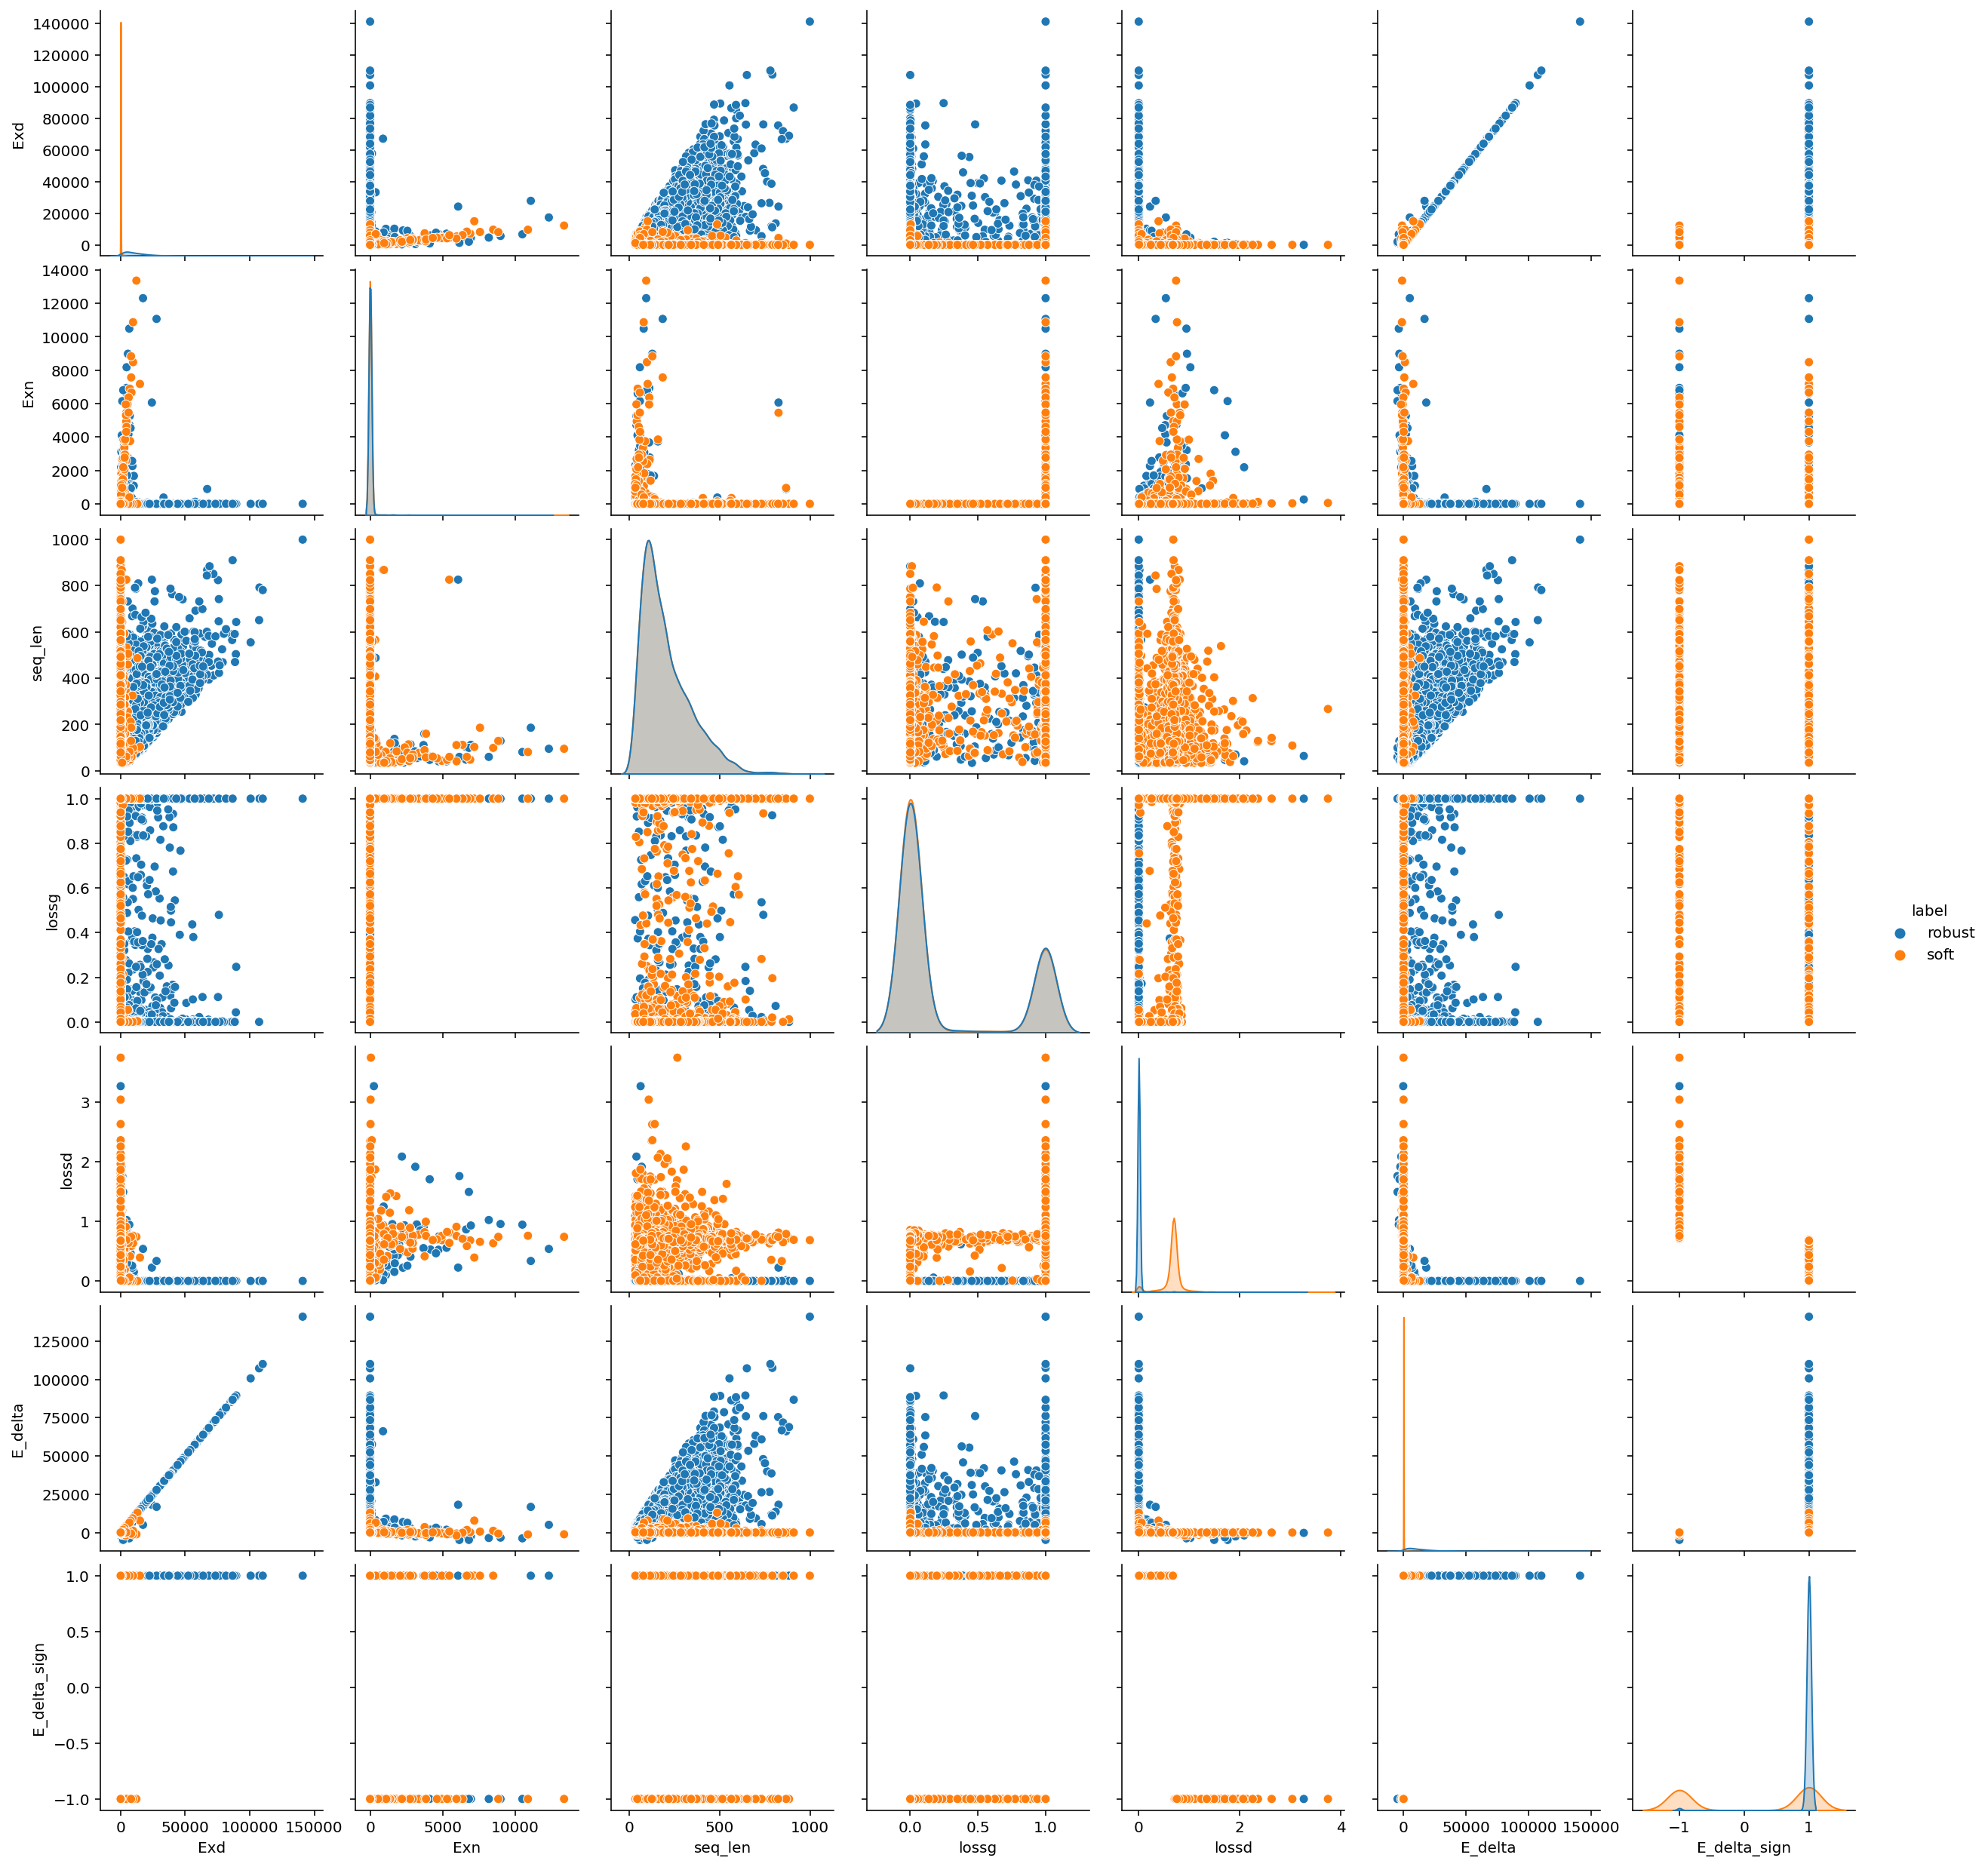

In [10]:
sns.pairplot(val_df, hue="label")

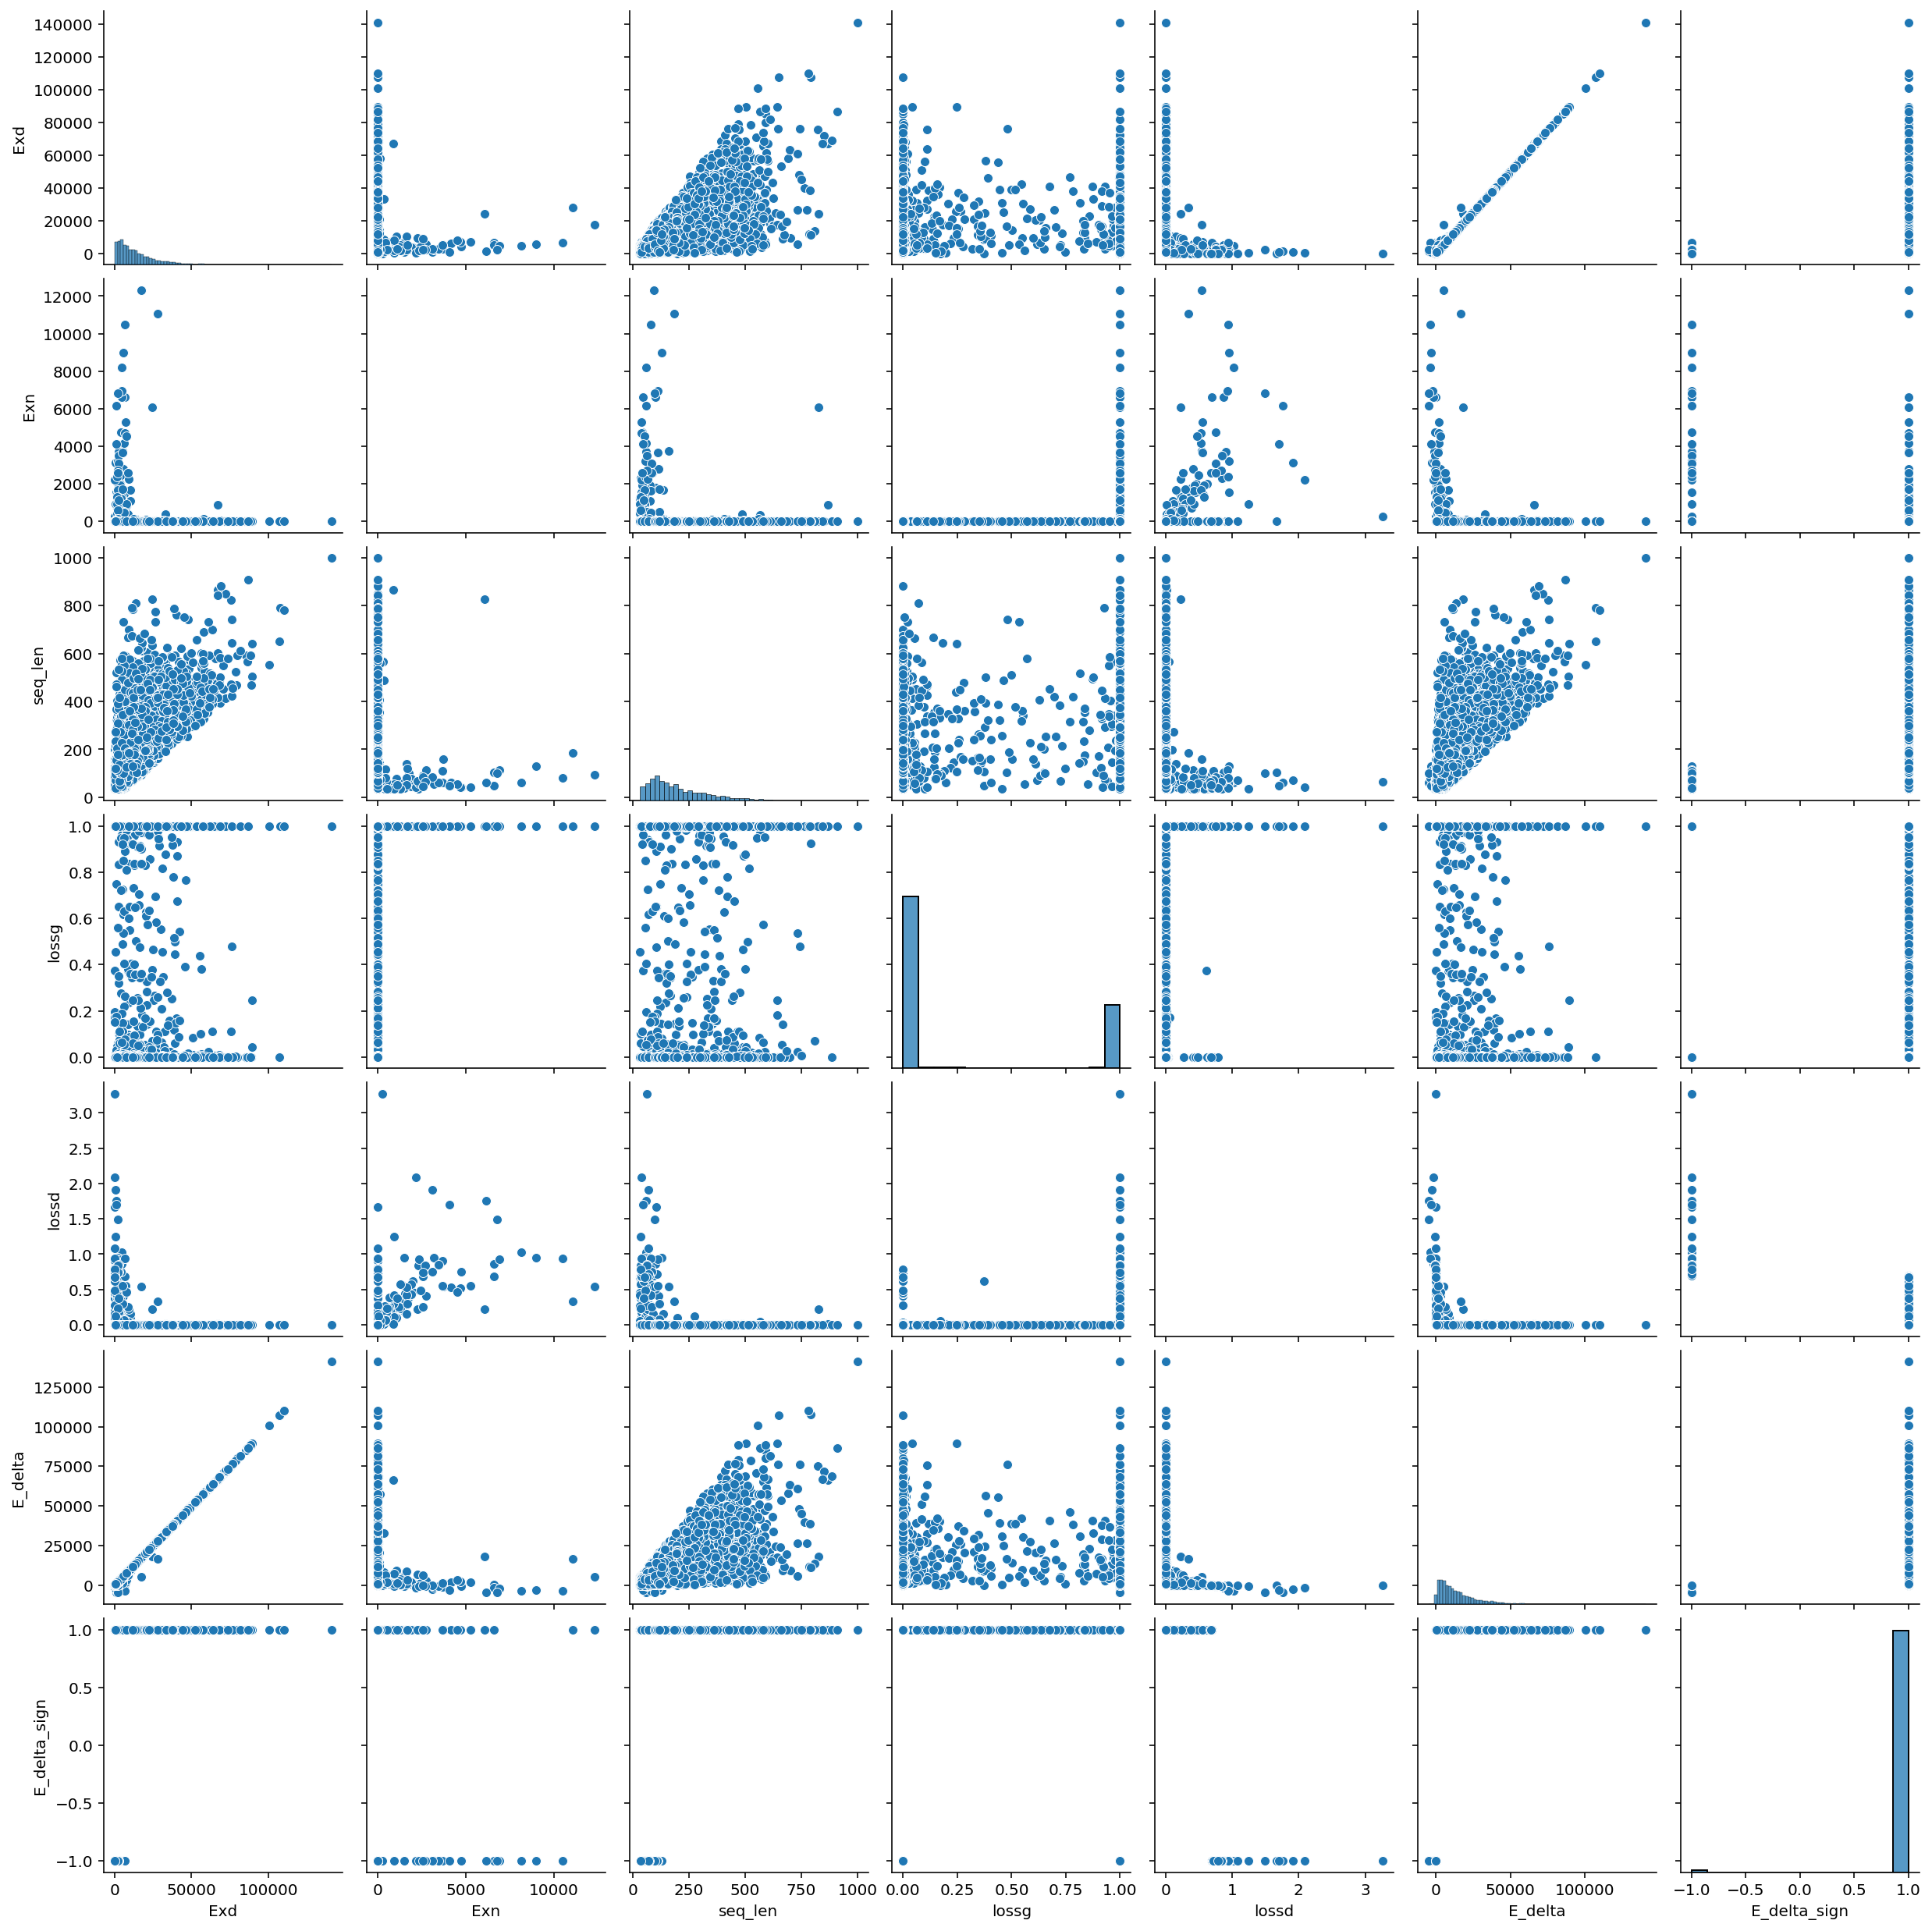

In [11]:
sns.pairplot(val_df_robust)

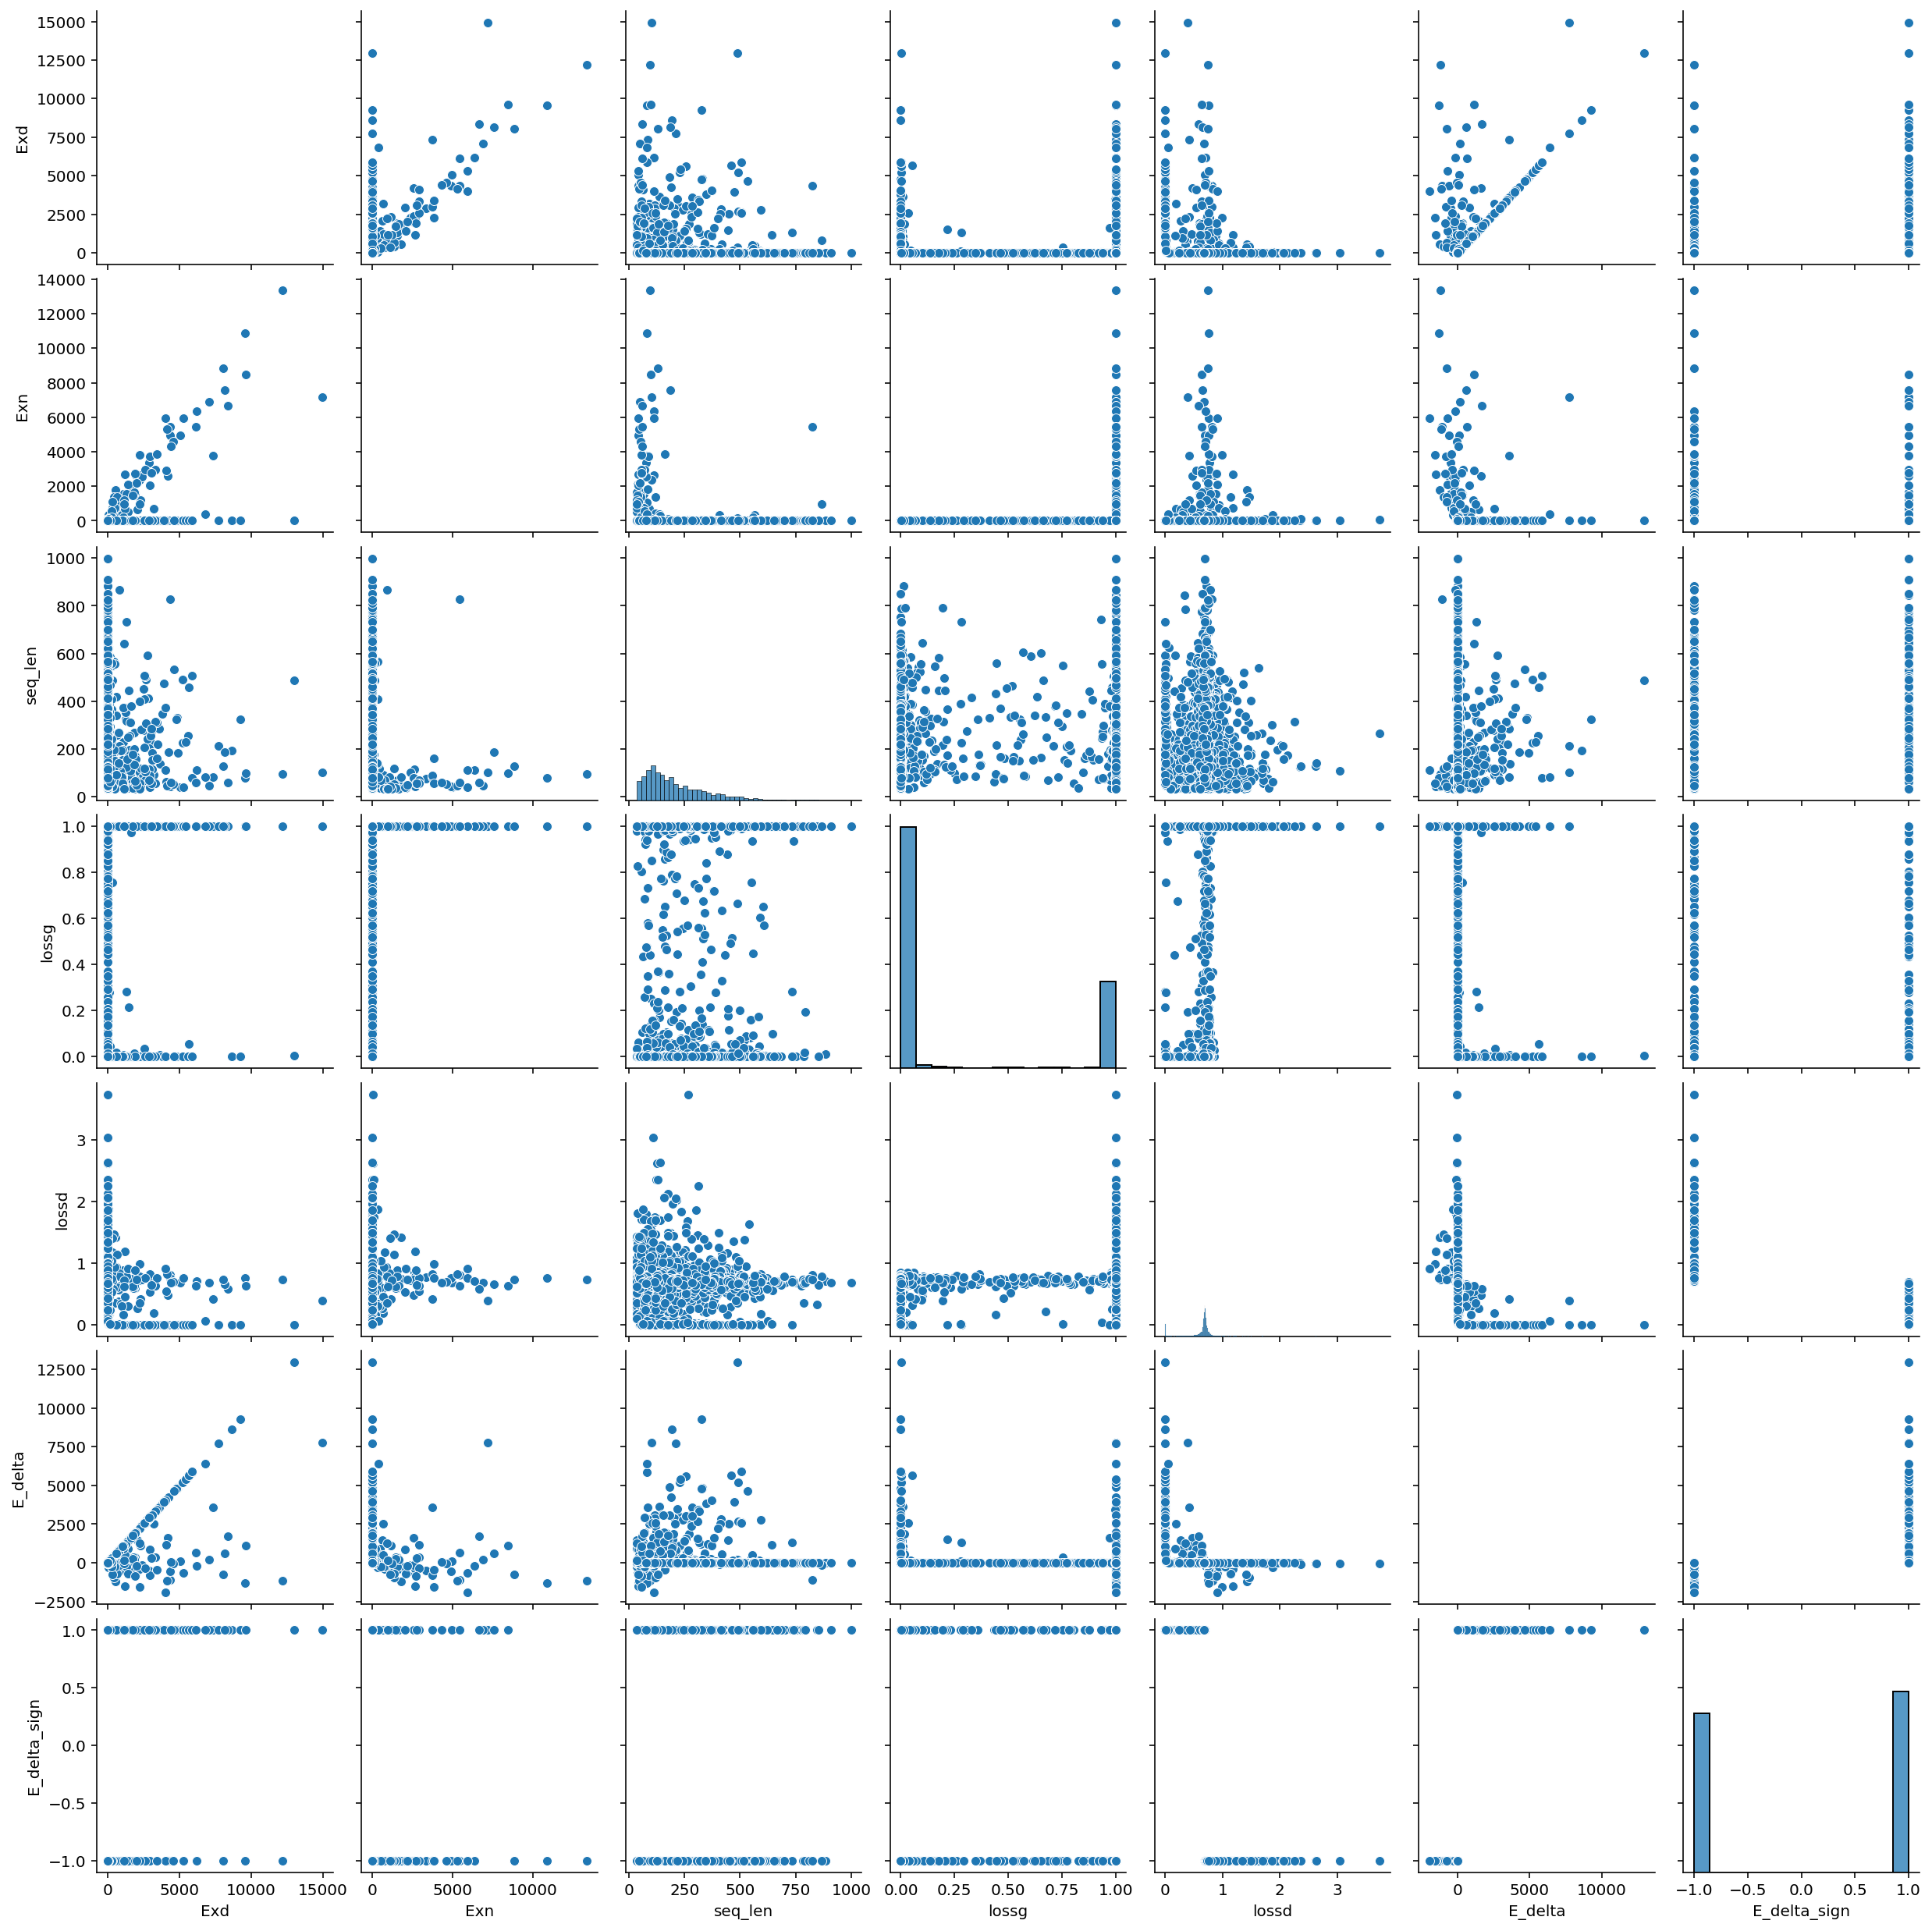

In [12]:
sns.pairplot(val_df_soft)

array([[<AxesSubplot:title={'center':'Exd'}>,
        <AxesSubplot:title={'center':'Exn'}>,
        <AxesSubplot:title={'center':'seq_len'}>],
       [<AxesSubplot:title={'center':'lossg'}>,
        <AxesSubplot:title={'center':'lossd'}>,
        <AxesSubplot:title={'center':'E_delta'}>],
       [<AxesSubplot:title={'center':'E_delta_sign'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

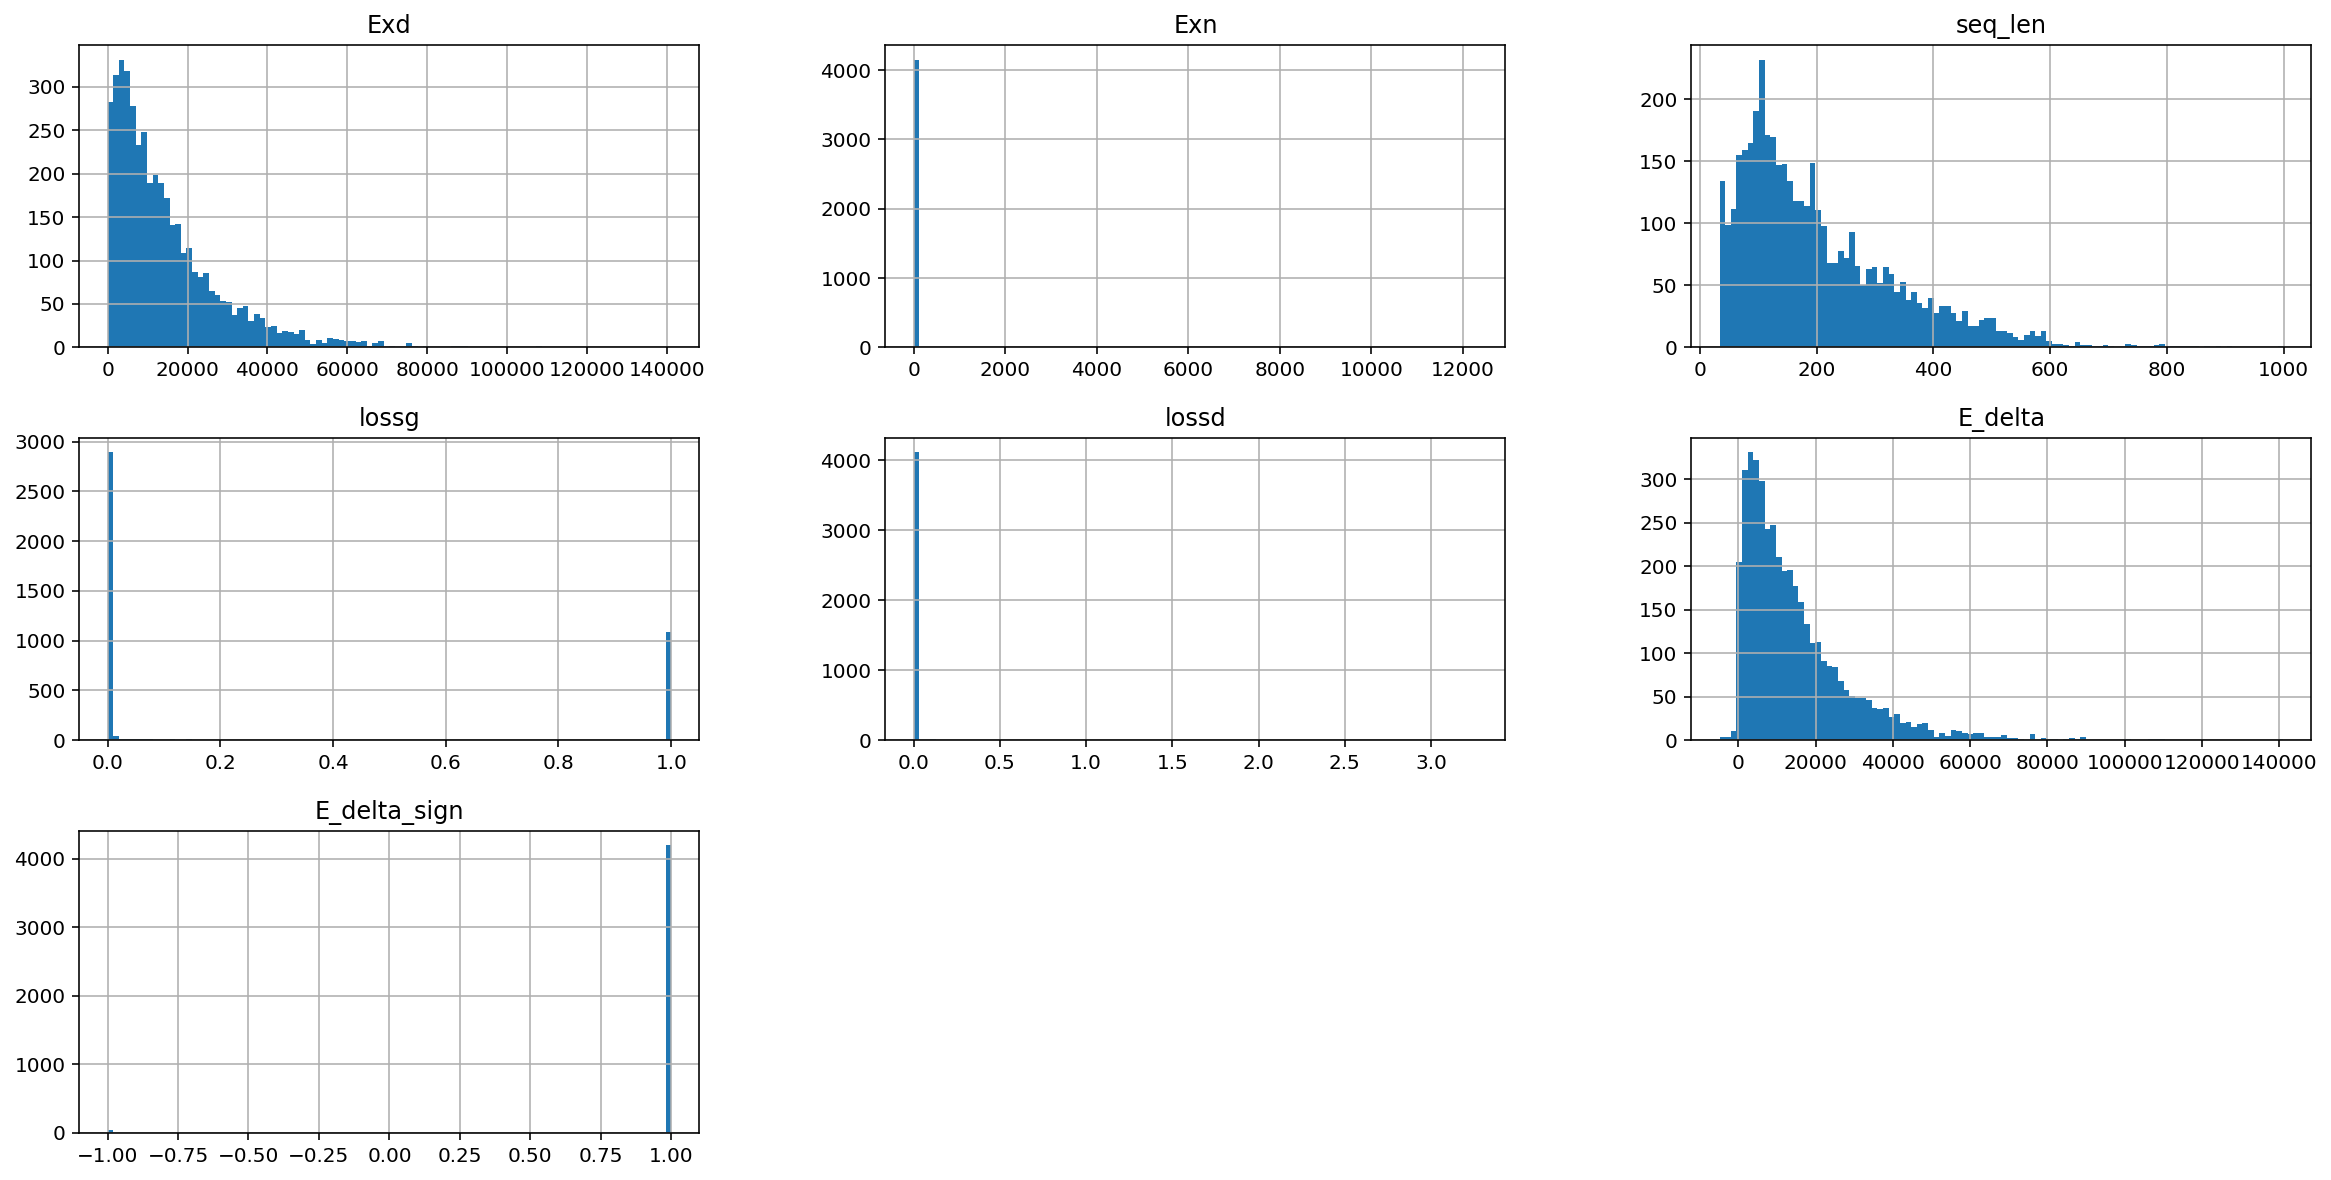

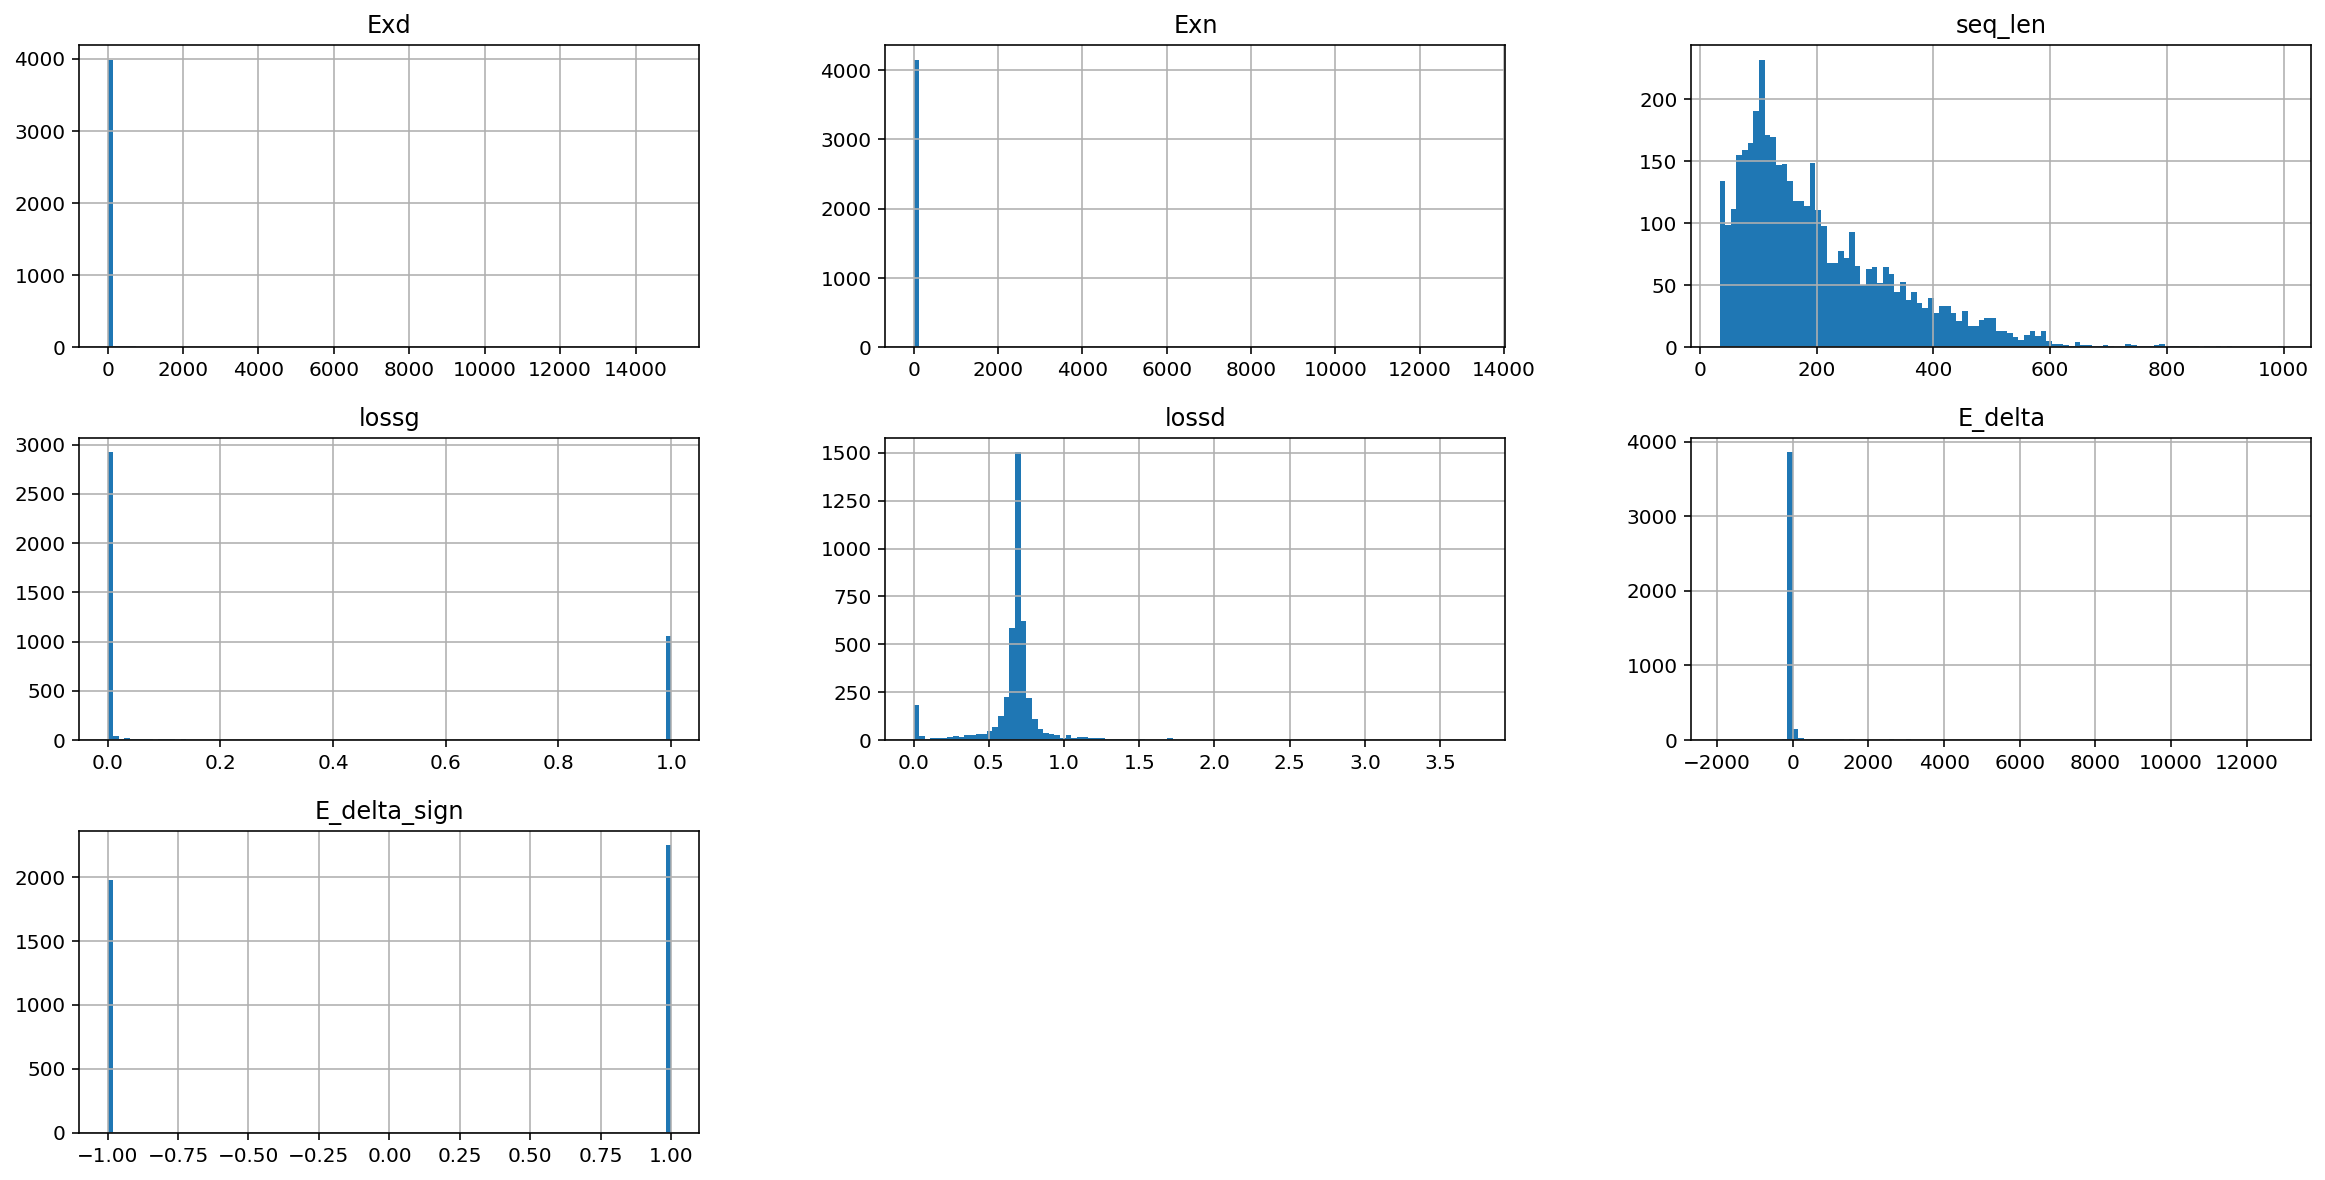

In [13]:
val_df_robust.hist( bins=100, figsize=(20, 10))
val_df_soft.hist( bins=100, figsize=(20, 10))

array([[<AxesSubplot:title={'center':'Exd'}>,
        <AxesSubplot:title={'center':'Exn'}>,
        <AxesSubplot:title={'center':'seq_len'}>],
       [<AxesSubplot:title={'center':'lossg'}>,
        <AxesSubplot:title={'center':'lossd'}>,
        <AxesSubplot:title={'center':'E_delta'}>],
       [<AxesSubplot:title={'center':'E_delta_sign'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

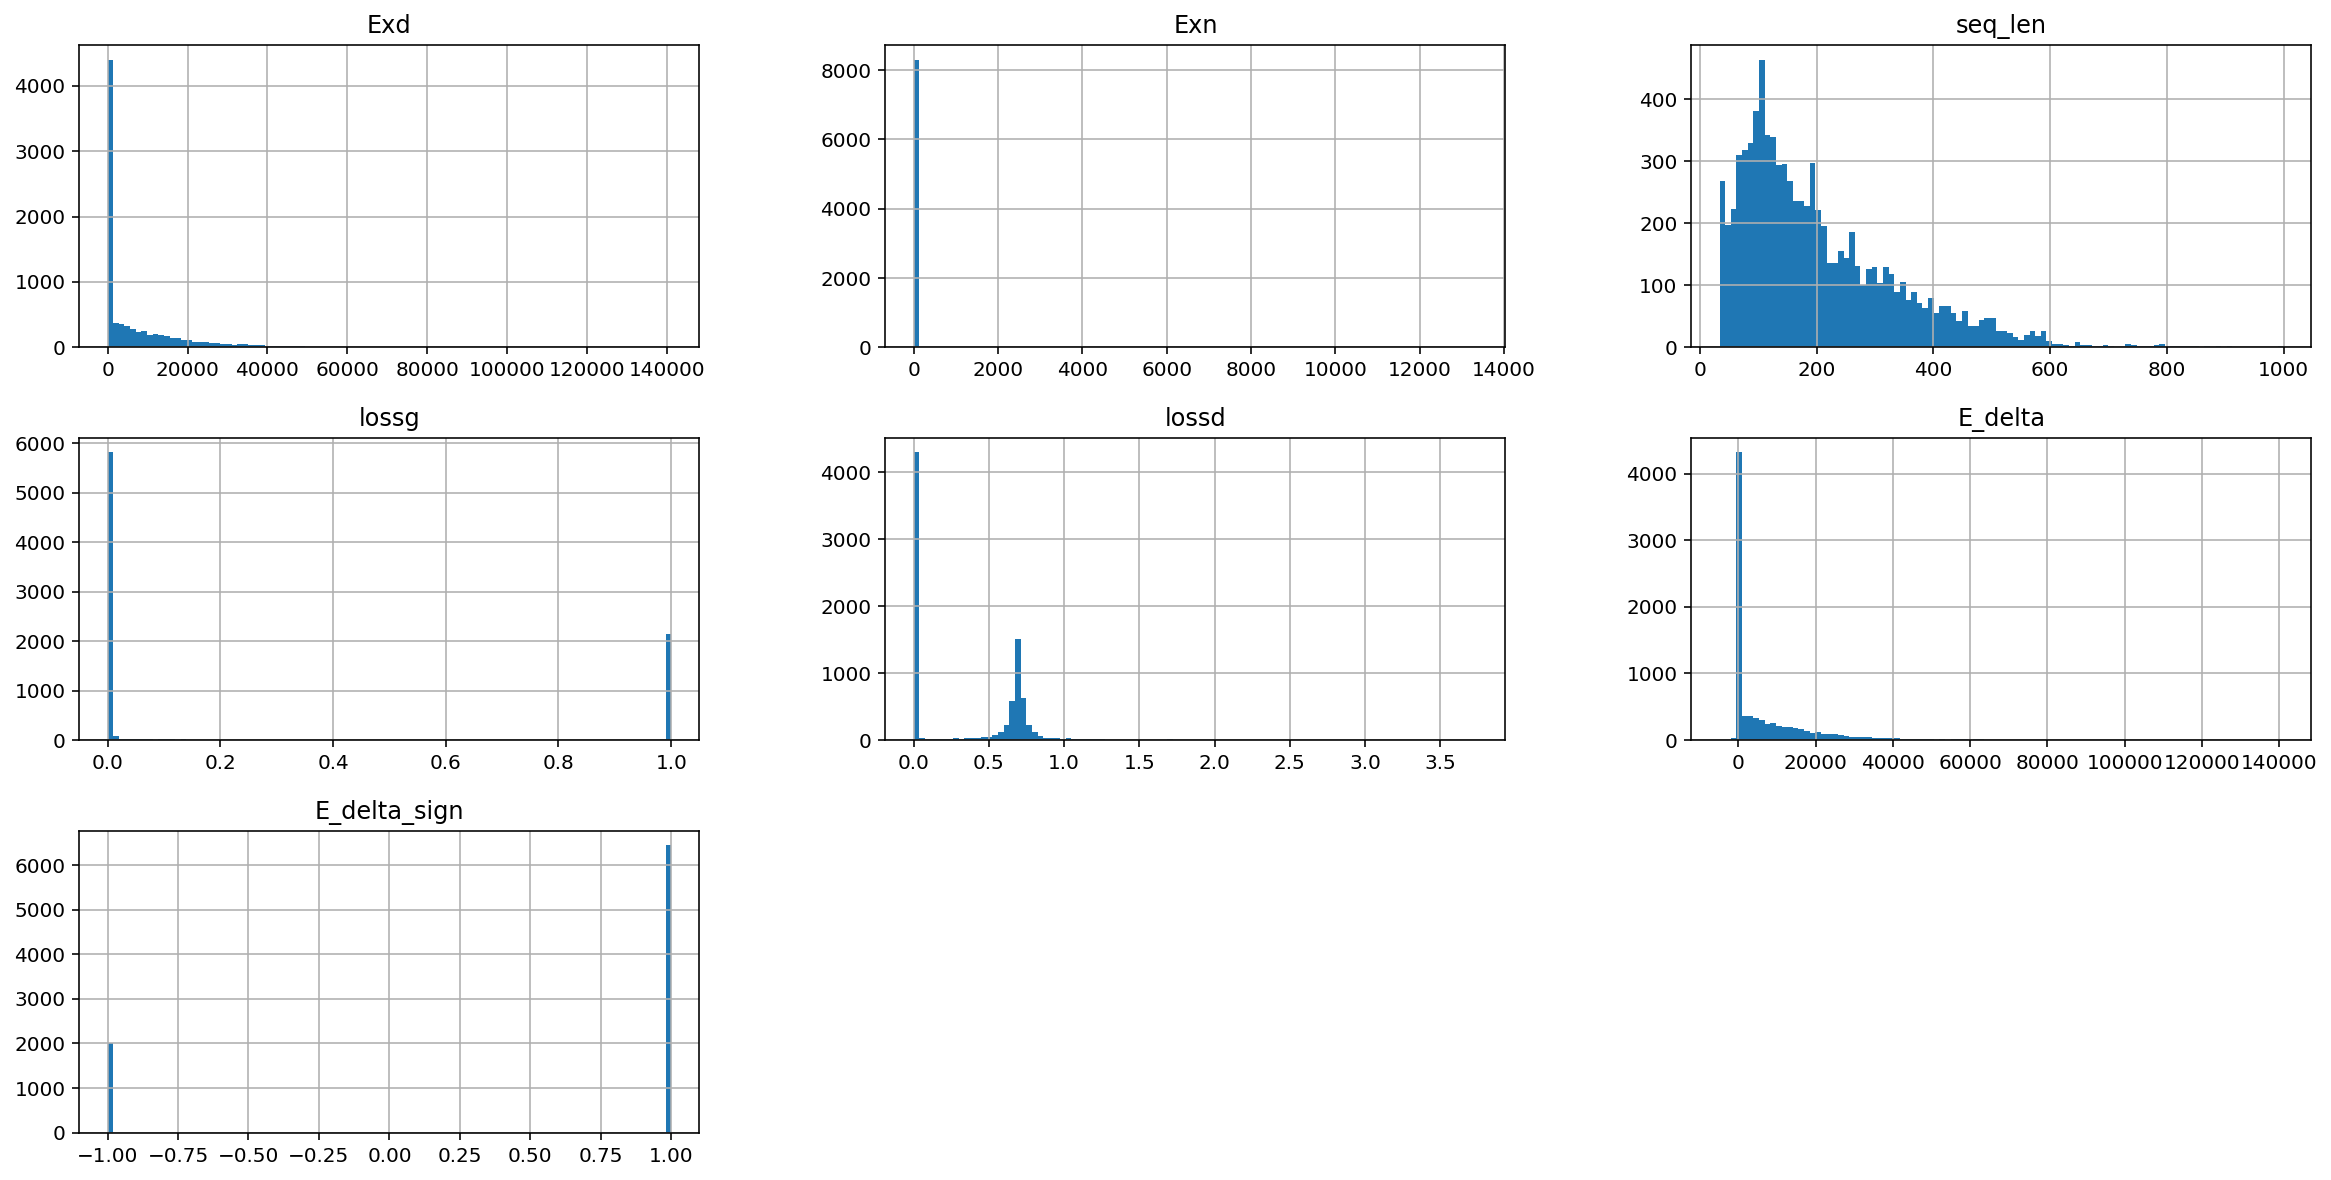

In [14]:
"""Plot the distribution of the predictions for the validation set"""
val_df.hist( bins=100, figsize=(20, 10))

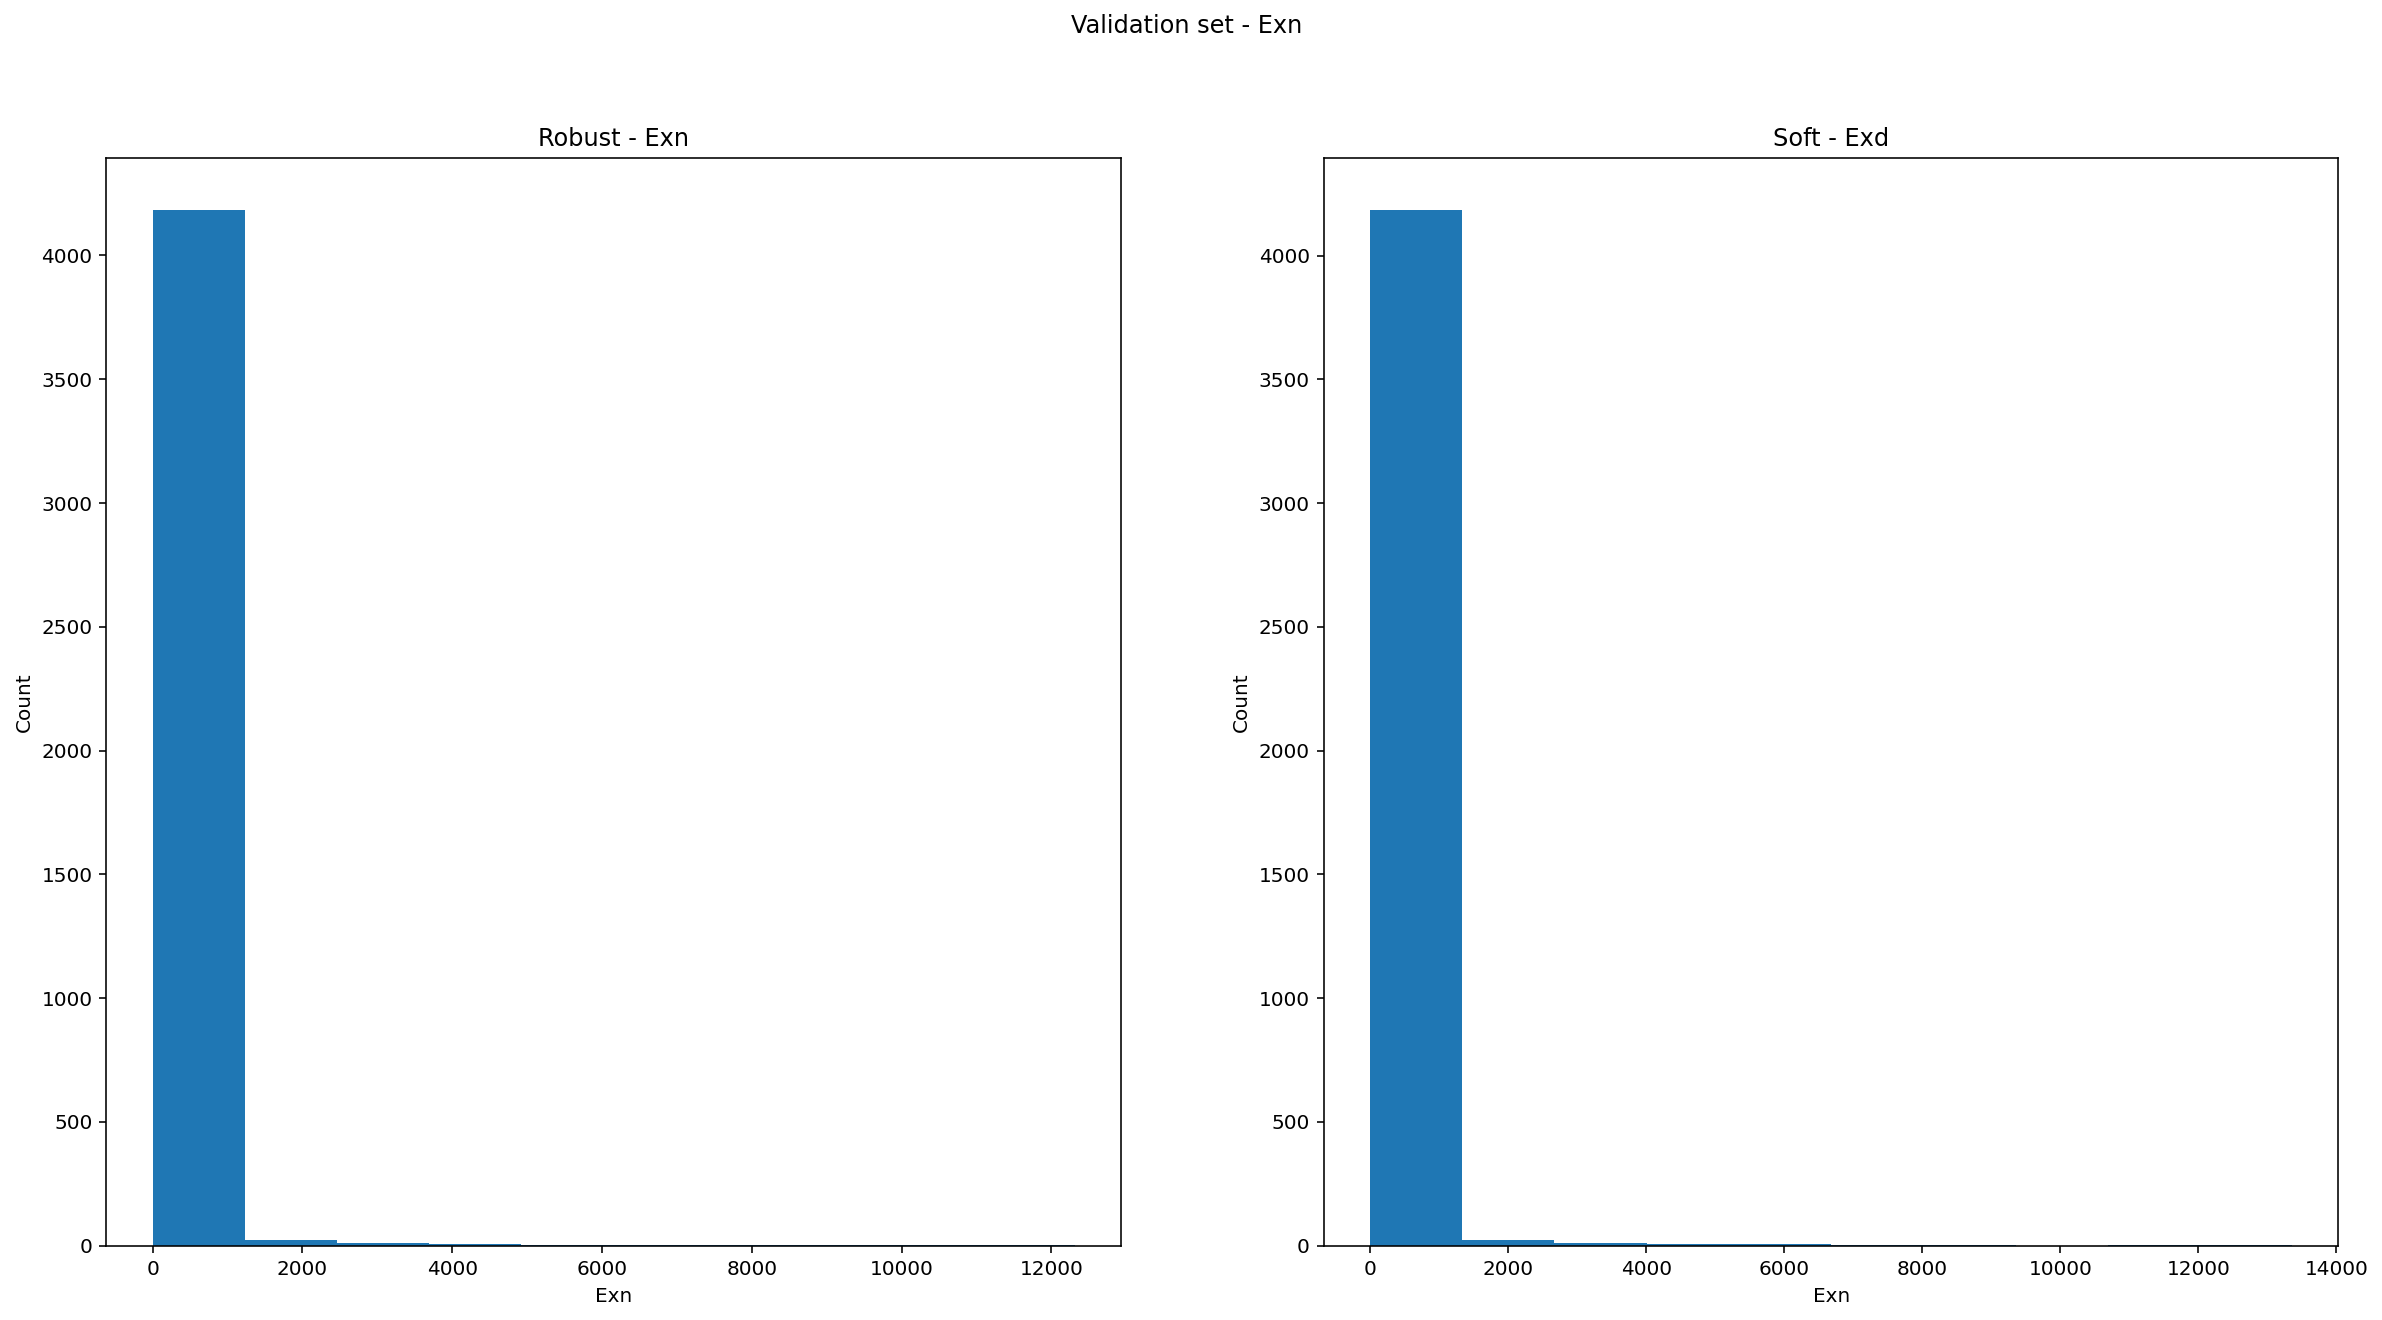

In [15]:
"""Plot the distribution of the predictions for the validation set"""
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.hist(val_df_robust['Exn'], bins=10)
plt.ylabel('Count')
plt.xlabel('Exn')
# plt.xlim(0, 1000)
plt.title('Robust - Exn')
plt.subplot(1, 2, 2)
plt.hist(val_df_soft['Exn'], bins=10)
plt.ylabel('Count')
plt.xlabel('Exn')
# plt.xlim(0, 1000)
plt.title('Soft - Exd')
plt.suptitle('Validation set - Exn')
plt.show()

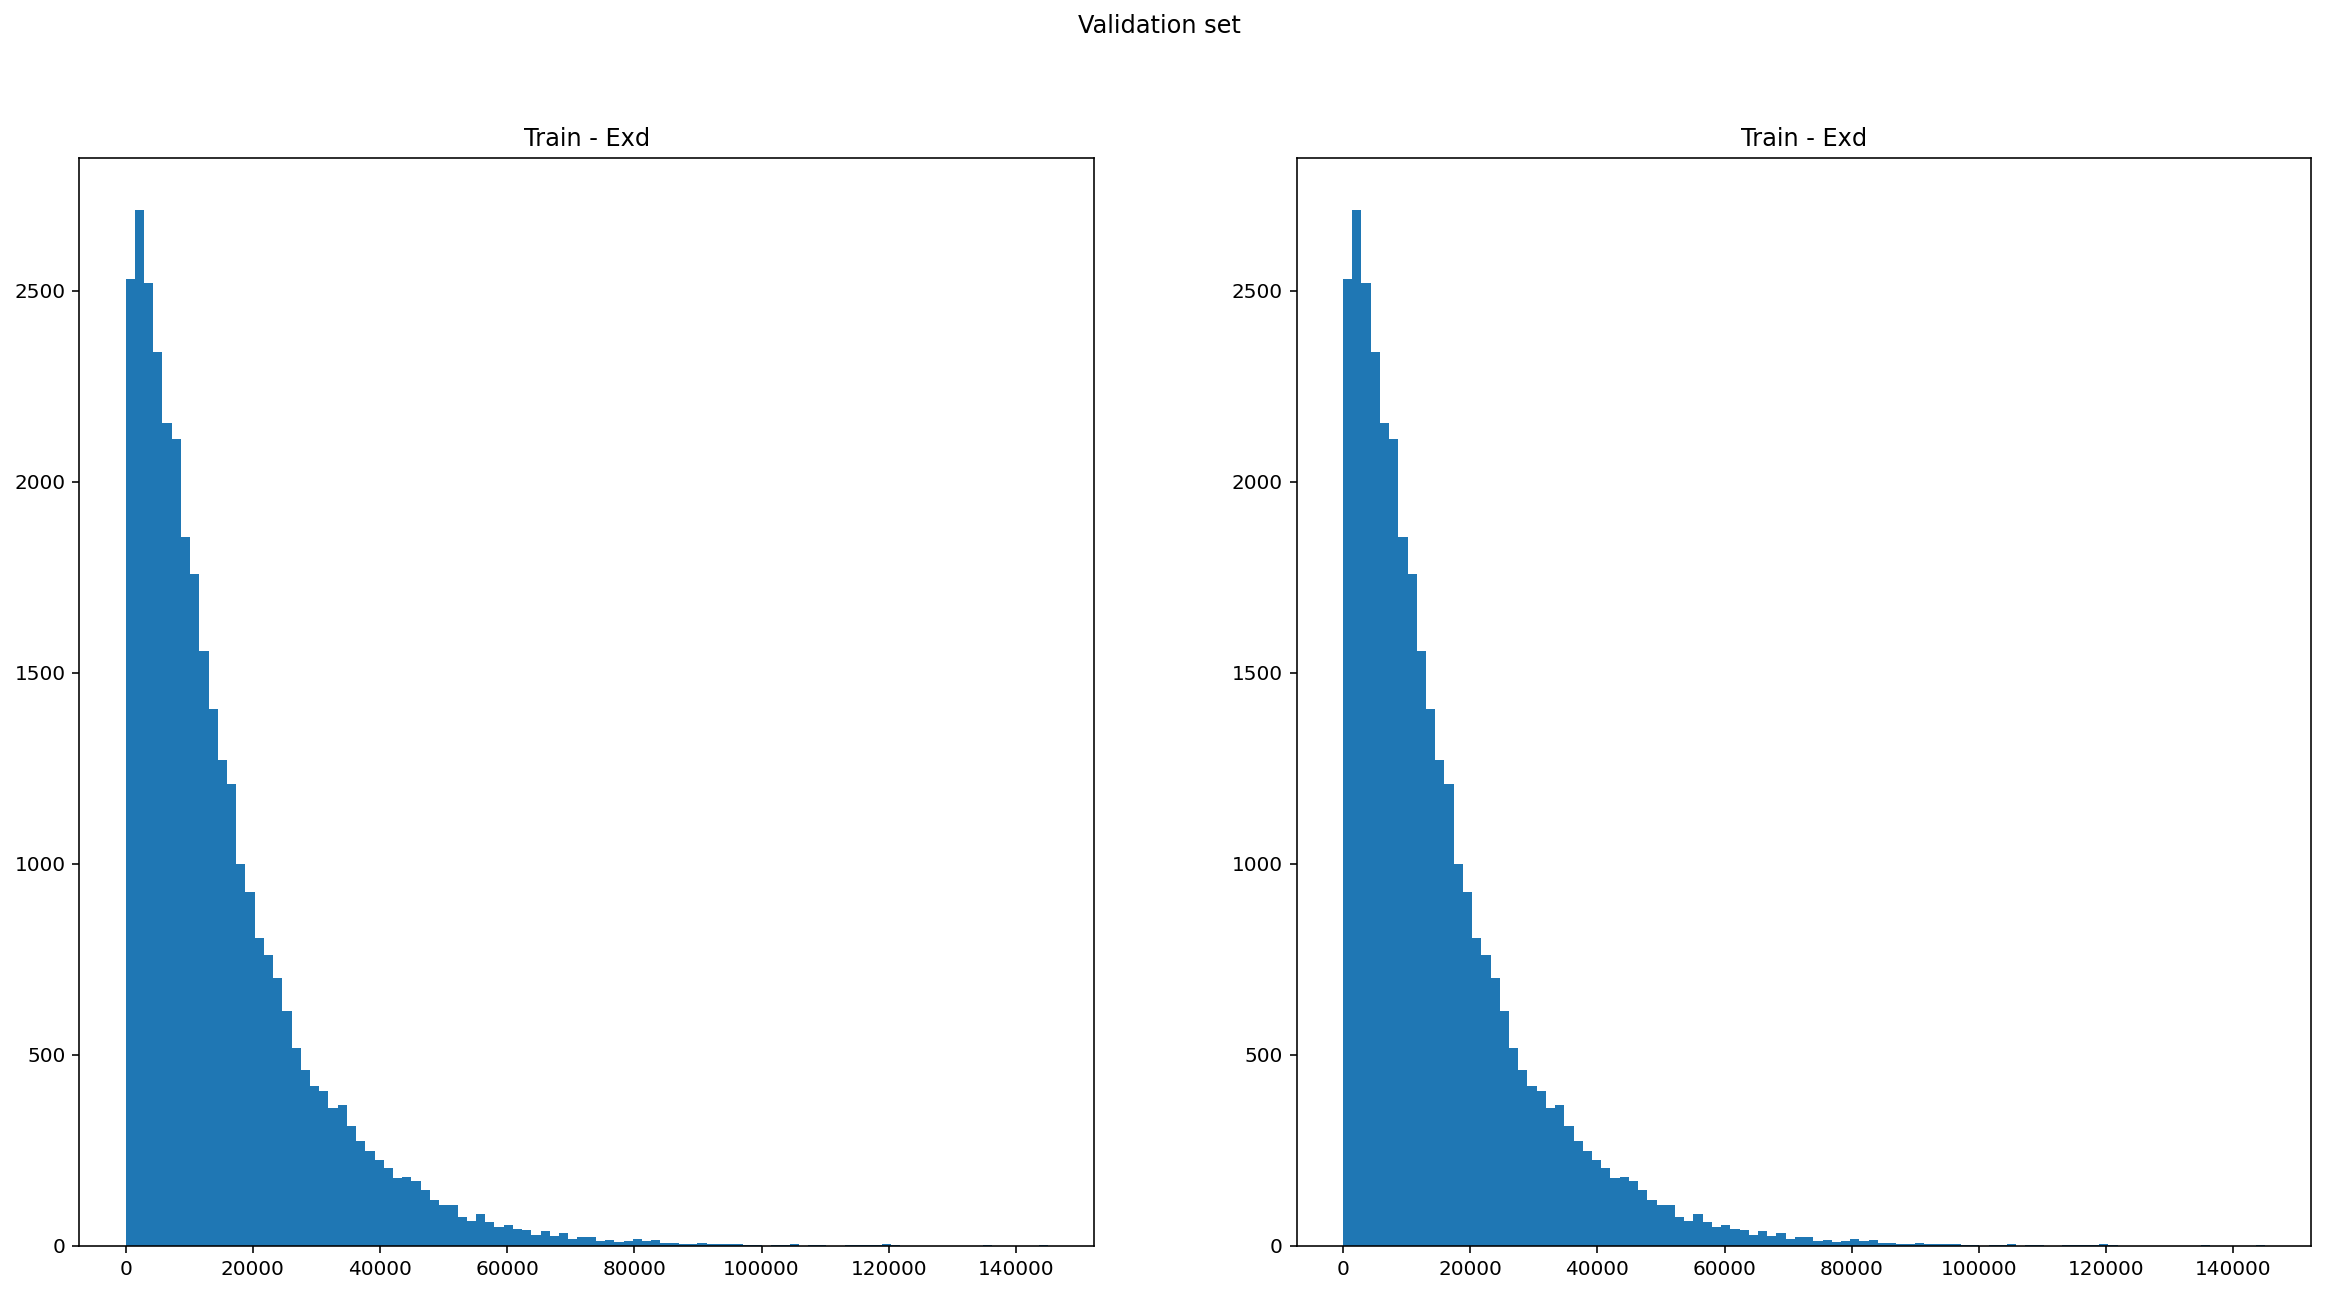

In [16]:
"""Plot the distribution of the predictions for the validation set"""
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.hist(train_df['Exd'], bins=100)
plt.title('Train - Exd')
plt.subplot(1, 2, 2)
plt.hist(train_df['Exd'], bins=100)
plt.title('Train - Exd')
plt.suptitle('Validation set')
plt.show()

In [17]:
print(f"Number of negative delta in the validation robust set: {len(val_df_robust[val_df_robust['E_delta'] < 0])} out of {len(val_df_robust)} samples")
print(f"Number of negative delta in the validation soft set: {len(val_df_soft[val_df_soft['E_delta'] < 0])} out of {len(val_df_soft)} samples")
print(f"Number of negative delta in the training set: {len(train_df[train_df['E_delta'] < 0])} out of {len(train_df)} samples")

Number of negative delta in the validation robust set: 35 out of 4235 samples
Number of negative delta in the validation soft set: 1982 out of 4235 samples
Number of negative delta in the training set: 242 out of 33844 samples


array([[<AxesSubplot:title={'center':'Exd'}>,
        <AxesSubplot:title={'center':'Exn'}>,
        <AxesSubplot:title={'center':'seq_len'}>],
       [<AxesSubplot:title={'center':'lossg'}>,
        <AxesSubplot:title={'center':'lossd'}>,
        <AxesSubplot:title={'center':'E_delta'}>],
       [<AxesSubplot:title={'center':'E_delta_sign'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

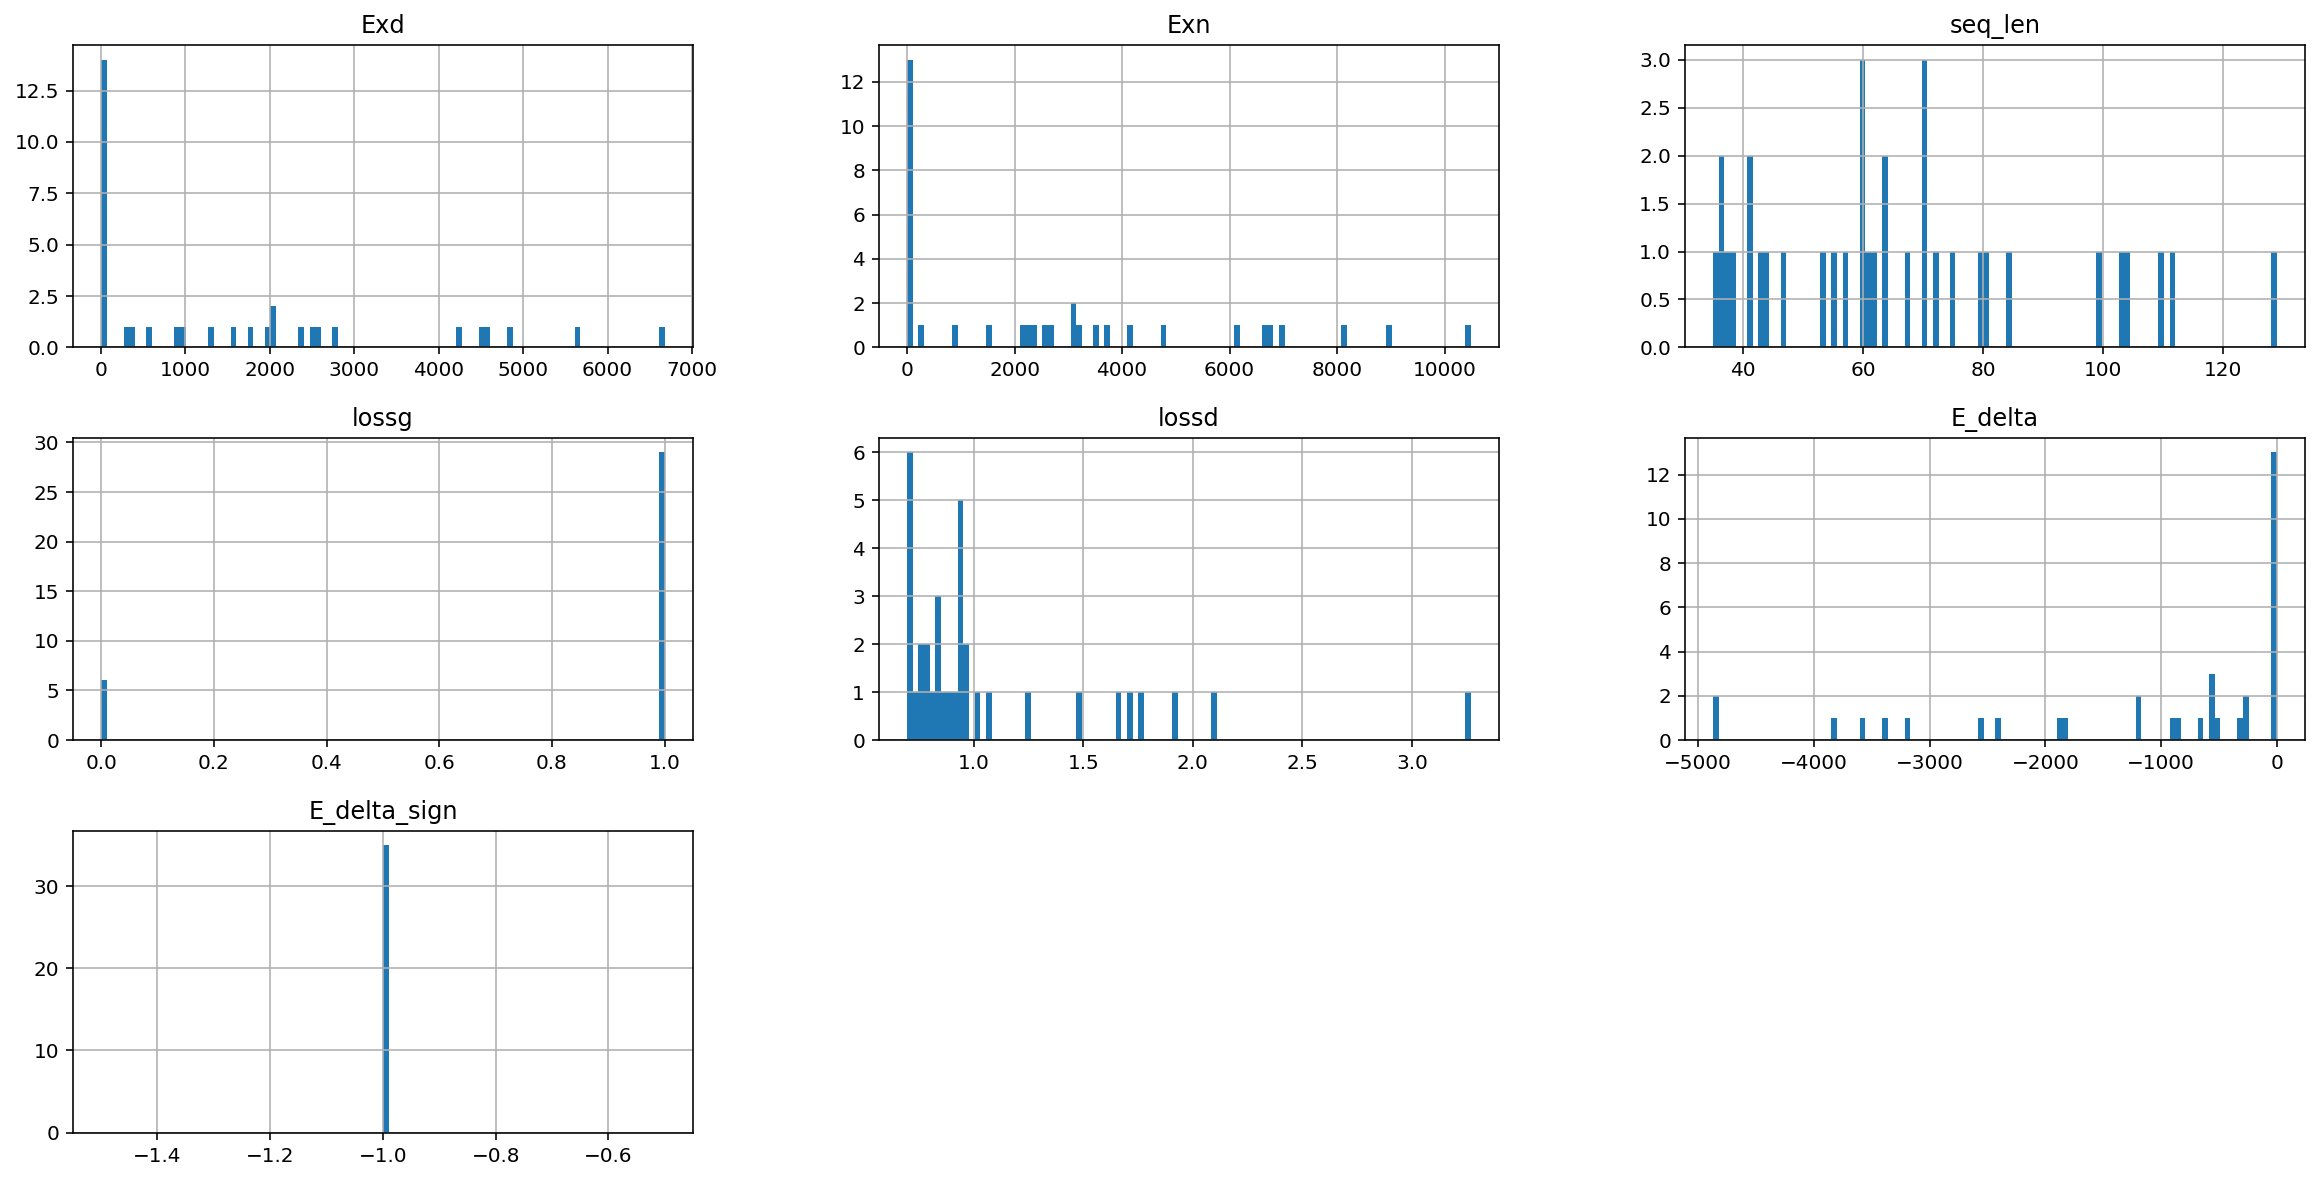

In [18]:
val_df_robust[val_df_robust['E_delta'] < 0].hist(bins=100, figsize=(20, 10))

In [5]:
# get top 5 delta
display(train_df.sort_values('E_delta', ascending=True).head(5))
display(train_df.sort_values('E_delta', ascending=False).head(5))

,id,Exd,Exn,seq_len,lossg,lossd,E_delta,E_delta_sign
0,['1TKN_1_A__AlphaFold2'],534.892395,12213.602540,110,1.0,3.169392,-11678.710145,-1.0
1,['1TKN_1_A__RoseTTAFold'],1073.857910,12446.387700,110,1.0,2.532148,-11372.529790,-1.0
2,['2V66_1_B__RoseTTAFold'],4179.675293,14986.077150,111,1.0,1.522757,-10806.401857,-1.0
3,['2R7G_d2r7gc2__RoseTTAFold'],3501.185059,12917.522460,143,1.0,1.545156,-9416.337401,-1.0
4,['4V7O_15_AE__RoseTTAFoldNT'],571.917358,8007.006348,76,1.0,2.706555,-7435.088990,-1.0


,id,Exd,Exn,seq_len,lossg,lossd,E_delta,E_delta_sign
33843,['3THX_1_A__AlphaFold2'],145020.2031,2.271752,934,1.0,0.000023,145017.931348,1.0
33842,['4W8Y_1_A__AlphaFold2'],135270.8438,1.589879,888,1.0,0.000019,135269.253921,1.0
33841,['4DVY_1_P__AlphaFold2'],121200.9297,65.088669,876,1.0,0.000545,121135.841031,1.0
33840,['3CWW_1_A__AlphaFold2'],119470.3594,1.699961,990,1.0,0.000023,119468.659439,1.0
33839,['2FGE_1_A__AlphaFold2'],119112.3359,1.709630,995,1.0,0.000023,119110.626270,1.0


In [93]:
def concat_cords(coordsAlpha,coordsBeta, coordsC, coordsN):
    """
    Concatenate the coordinates
    output: X (torch.tensor): concatenated coordinates [N,4,3]
    """
    coordsAlpha,coordsBeta, coordsC, coordsN = coordsAlpha.unsqueeze(1), coordsBeta.unsqueeze(1), coordsC.unsqueeze(1), coordsN.unsqueeze(1)
    X = torch.cat((coordsAlpha,coordsBeta, coordsC, coordsN), dim=1)
    return X

def getCB(N, CA, C):
        # CB = CA + c1*(N-CA) + c2*(C-CA) + c3* (N-CA)x(C-CA)
        dt = torch.get_default_dtype()
        N = N.to(dt)
        CA = CA.to(dt)
        C = C.to(dt)

        CAmN = N - CA
        # CAmN = CAmN / torch.sqrt(CAmN ** 2).sum(dim=2, keepdim=True)
        CAmC = C - CA
        # CAmC = CAmC / torch.sqrt(CAmC ** 2).sum(dim=2, keepdim=True)
        ANxAC = torch.cross(CAmN, CAmC, dim=1)

        A = torch.cat((CAmN.reshape(-1, 1), CAmC.reshape(-1, 1), ANxAC.reshape(-1, 1)), dim=1)
        c = torch.tensor([0.5507, 0.5354, -0.5691]) / 100  # torch.tensor([1.1930, 1.2106, -2.7906]) #
        b = (A @ c).reshape(-1,3)
        CB = CA - b

        return CB

In [94]:
import torch
import os
import matplotlib.pyplot as plt

NANO_TO_ANGSTROM = 0.1
index_path = '../data/inference_data/25154'
index_path = '../data/inference_data/34145'
def get_inference_data(folder):
    index_path = os.path.join('../data/inference_data', folder)
    # Sequence of the protein
    seq = torch.load(os.path.join(index_path, 'seq.pt'))
    seq_decoy = seq[:,torch.randperm(seq.shape[1])]
    id = torch.load(os.path.join(index_path, 'ids.pt')) # string id
    # 3D coordinates of the protein
    coordsAlpha = torch.load(os.path.join(index_path, 'CoordAlpha.pt'))
    coordsBeta = torch.load(os.path.join(index_path, 'CoordBeta.pt'))   
    coordsC = torch.load(os.path.join(index_path, 'CoordC.pt'))
    coordsN = torch.load(os.path.join(index_path, 'CoordN.pt'))
    # 3D coordinates of the protein native
    coordsAlpha_native = torch.load(os.path.join(index_path, 'CoordCaNative.pt'))
    coordsBeta_native = torch.load(os.path.join(index_path, 'CoordCbNative.pt'))
    coordsC_native = torch.load(os.path.join(index_path, 'CoordCNative.pt'))
    coordsN_native = torch.load(os.path.join(index_path, 'CoordNNative.pt'))
    # Check glycine value
    glyIndices = torch.where(coordsBeta_native[:,0] > 5e4)[0]
    if torch.any(glyIndices):
        coordsBeta_native[glyIndices,:] = getCB(coordsN_native[glyIndices,:], coordsAlpha_native[glyIndices,:], coordsC_native[glyIndices,:])
    #     # Check glycine value decoy
    # glyIndices = torch.where(coordsBeta[:, 0] > 5e4)[0]
    # if torch.any(glyIndices):    
    #     coordsBeta[glyIndices,:] = self.getCB(coordsN[glyIndices,:], coordsAlpha[glyIndices,:], coordsC[glyIndices,:])
    # Masks
    mask = torch.load(os.path.join(index_path, 'mask.pt'))
    nativemask = torch.load(os.path.join(index_path, 'nativemask.pt'))
    # Embeddings
    n_nodes= coordsAlpha.shape[0]
    # esm_embed = torch.stack(torch.load(os.path.join(index_path, 'emb_esm.pt')))[0][:10]
    # esm_embed = esm_embed.repeat(n_nodes,1)
    # Concatenate the coordinates
    Xd = concat_cords(coordsAlpha,coordsBeta, coordsC, coordsN)
    Xn = concat_cords(coordsAlpha_native,coordsBeta_native, coordsC_native, coordsN_native)

    # Convert nno to angstrom
    Xd = Xd * NANO_TO_ANGSTROM
    Xn = Xn * NANO_TO_ANGSTROM
    
    print(id)
    print(f"sequence length: {seq.shape[1]} ")
    display(nativemask)
    # print distance matrix
    N_residu,N_atoms,coords_size = Xd.shape
    Xn = Xn.reshape(N_residu*N_atoms,coords_size)
    D = torch.cdist(Xn,Xn,p=2)
    D = D.reshape(N_residu,N_atoms,N_residu,N_atoms)
    D = torch.swapaxes(D,1,2)
    D = D.reshape(N_residu,N_residu,N_atoms*N_atoms)
    # plot heatmap of the distance matrix

    plt.figure(figsize=(20, 10))
    plt.imshow(D[:,:,1].squeeze().numpy(), cmap='magma', interpolation='nearest')
    plt.colorbar()

1TKN_1_A__AlphaFold2
sequence length: 110 


tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

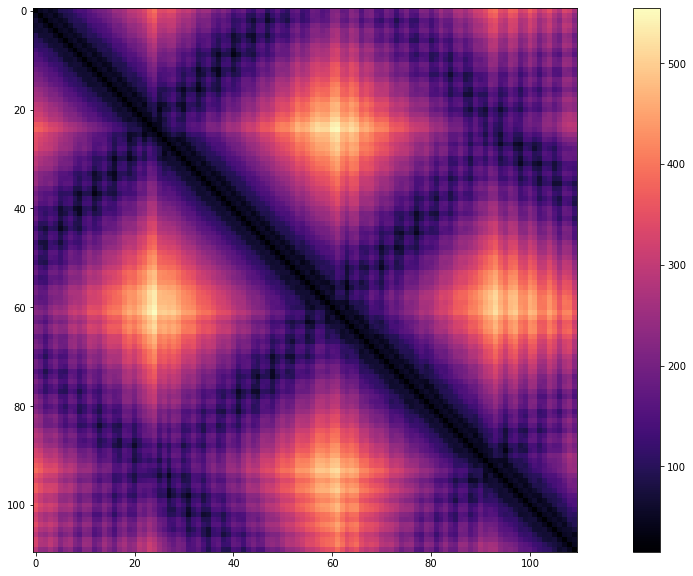

In [95]:
get_inference_data("25154")

2V66_1_B__RoseTTAFold
sequence length: 111 


tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

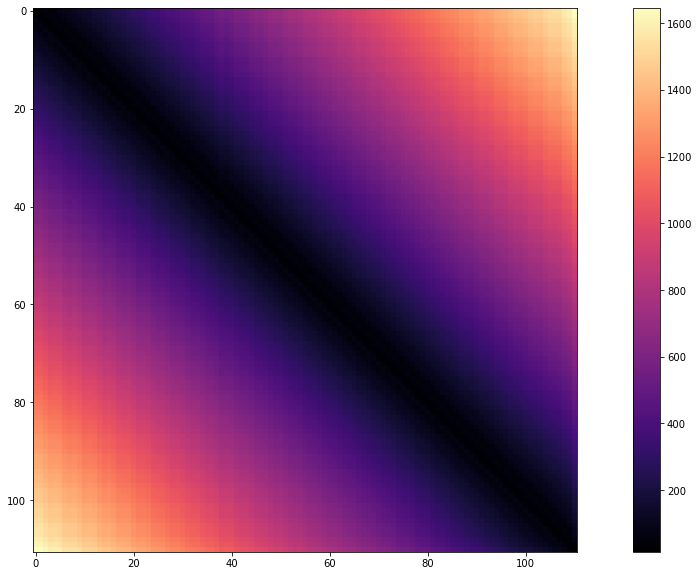

In [96]:
get_inference_data("34145")

2R7G_d2r7gc2__RoseTTAFold
sequence length: 143 


tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

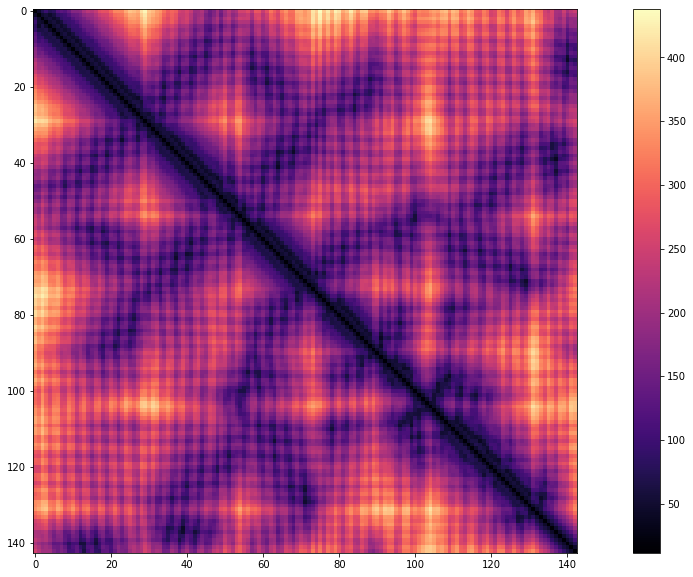

In [97]:
get_inference_data("9141")

## Inference of high delta proteins

3THX_1_A__AlphaFold2
sequence length: 934 


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

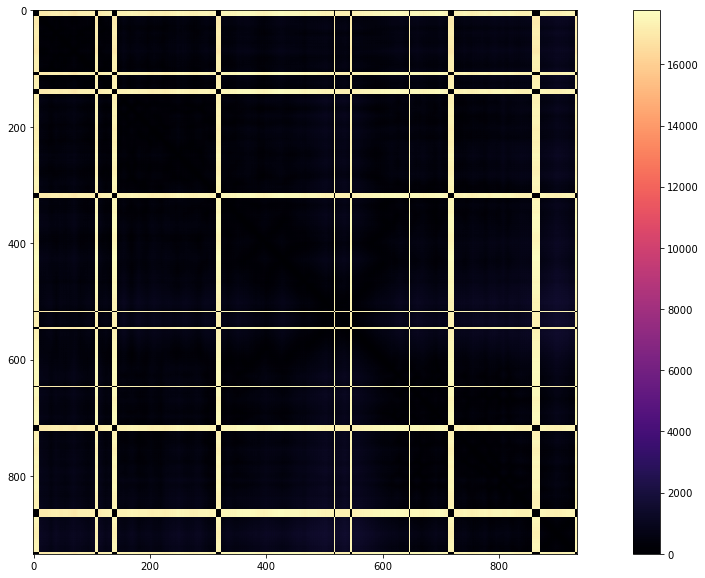

In [71]:
get_inference_data("18137")

4W8Y_1_A__AlphaFold2
sequence length: 888 


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

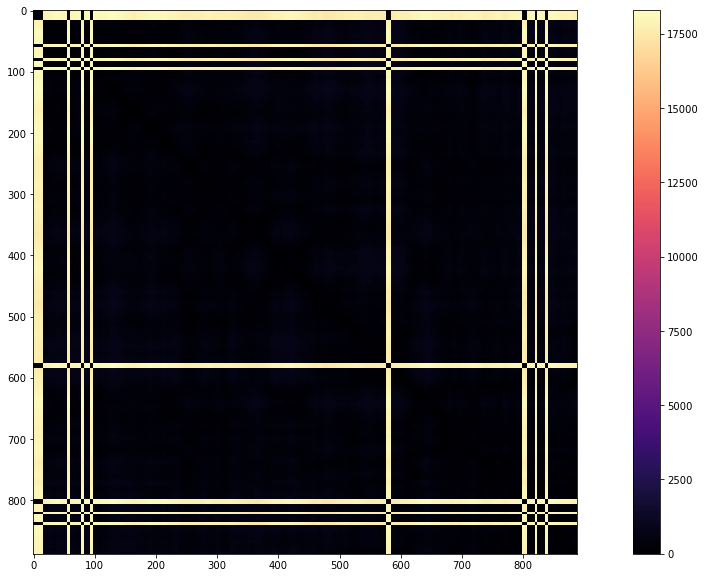

In [72]:
get_inference_data("19745")

4DVY_1_P__AlphaFold2
sequence length: 876 


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

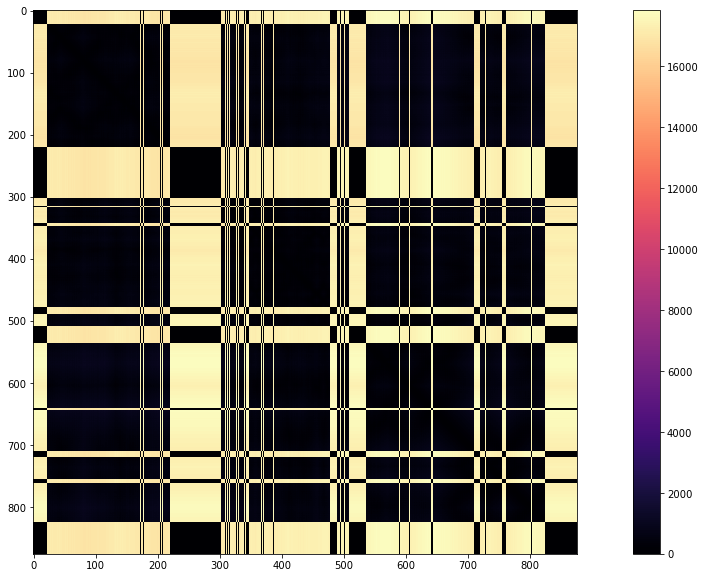

In [64]:
get_inference_data("18572")

## Inference closest to zero

2FXM_1_A__AlphaFold2
sequence length: 129 


tensor([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1])

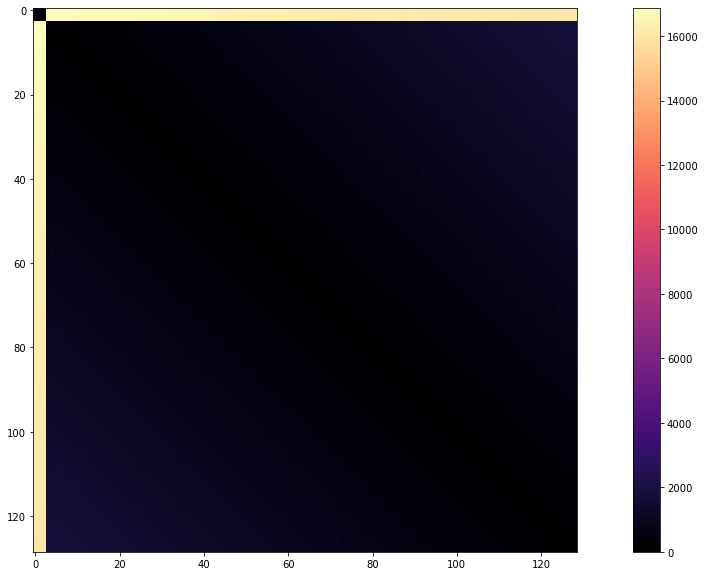

In [73]:
get_inference_data("29540")

10#1JB0_12_X__RoseTTAFold
sequence length: 35 


tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

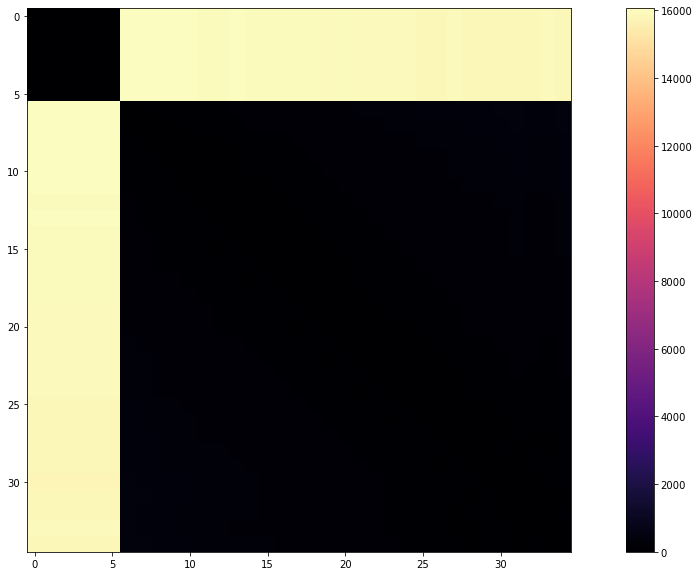

In [66]:
get_inference_data("2")

In [6]:
import torch

# Create a sample tensor
tensor = torch.tensor([[[0, 0, 0], [4, 5, 6], [7, 8, 9]],
                       [[10, 11, 12], [0, 0, 0], [16, 17, 18]],
                       [[19, 20, 21], [22, 23, 24], [0, 0, 0]]])
tensor.shape

torch.Size([3, 3, 3])

In [43]:
import torch

tensor = torch.rand(10 * 4, 3)

# create distance matrix
distance_matrix = torch.cdist(tensor, tensor, p=2)
distance_matrix = distance_matrix.reshape(10, 4, 10, 4)
distance_matrix = torch.swapaxes(distance_matrix, 1, 2)
distance_matrix = distance_matrix.reshape(10, 10, 4 * 4)

print(distance_matrix.shape)
n_res = 10 # number of residues
# get above diagonal indexes
n_range = torch.arange(n_res)
print(n_range[:-1].shape)
# get the distance matrix values above the diagonal (without the diagonal)
f1 ,f2 = distance_matrix[n_range[:-1], n_range[1:], :] , distance_matrix[n_range[1:], n_range[:-1], :]
# show the distance matrix values
print(f1.shape)
print(f2.shape)


torch.Size([10, 10, 16])
torch.Size([9])
torch.Size([9, 16])
torch.Size([9, 16])


In [44]:
# Add zero row at the start
zero_row = torch.zeros(1, 16)
f2 = torch.cat((zero_row, f2), dim=0)
# add zero column at the end
f1 = torch.cat((f1, zero_row), dim=0)
# print the new shapes
print(f1.shape)
print(f2.shape)

torch.Size([10, 16])
torch.Size([10, 16])


In [47]:
new_features = torch.cat((f1, f2), dim=1)
new_features.shape

torch.Size([10, 32])

In [51]:
def get_bonded_features(D):
    """Get bonded features from distance matrix"""
    n_range = torch.arange(D.shape[0])
    # get abobve and below diagonal
    f1, f2 = D[n_range[:-1], n_range[1:]], D[n_range[1:], n_range[:-1]]
    # pad with zeros
    zero_row = torch.zeros((1, D.shape[-1])).to(D.device)
    f1 = torch.cat([f1, zero_row], dim=0)
    f2 = torch.cat([zero_row, f2], dim=0)
    # concat features
    Fb = torch.cat([f1, f2], dim=-1)
    return Fb 

distance_matrix.shape
print (get_bonded_features(distance_matrix).shape)

torch.Size([10, 32])
